# FinTrust Digital Bank — Week 3: Predictive Risk Model (Advanced Development & Validation)

### Predictive problem (carried from Weeks 1–2)
*Given a transaction's recorded attributes, can we predict whether it was marked `Risk_Review_Flag = Yes` (i.e. "requires risk review")?*
The intended user is a risk-review analyst who needs transactions **prioritised** for manual review.

### How this notebook maps to the Week 3 Data Science assignment
| Part | Section | Part | Section |
|---|---|---|---|
| A | 2. Review of the Week 2 baseline | E | 6. Error analysis |
| B | 4. Additional models | F | 7. Model interpretation |
| C | 3. Feature refinement | G | 8. Candidate final model |
| D | 5. Model comparison | — | 9. Validation evidence · 10. Assumptions/limitations · 11. Week 3 summary |

## Libraries

In [1]:
import os, json, warnings, platform, joblib, sklearn
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import chi2_contingency
from pathlib import Path

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, GroupKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
np.random.seed(SEED)

OUT = "week3_outputs"; FIG = f"{OUT}/figures"
os.makedirs(FIG, exist_ok=True)

In [2]:
DATA_PATH = r"D:\Analyst_lab\FinTrust_Digital_Bank_Project\data\processed\FinTrust_Modelling_Dataset_Prepared.csv"   # the prepared dataset used for the Week 2 baseline
prepared = pd.read_csv(DATA_PATH)
print("Week 2 prepared dataset:", prepared.shape)

Week 2 prepared dataset: (12000, 22)


### Data quality re-checks

In [3]:
checks = {
 "Duplicate Transaction_ID rows": int(prepared.Transaction_ID.duplicated().sum()),
 "Missing values (any column)": int(prepared.isna().sum().sum()),
 "Device_Type = 'Unknown' (filled in Week 2)": int((prepared.Device_Type == "Unknown").sum()),
 "Location = 'Unknown' (filled in Week 2)": int((prepared.Location == "Unknown").sum()),
 "Non-positive Amount_NGN": int((prepared.Amount_NGN <= 0).sum()),
 "Unparseable Transaction_DateTime": int(pd.to_datetime(prepared.Transaction_DateTime, errors="coerce").isna().sum()),
 "Risk_Review_Target disagrees with Risk_Review_Flag": int(((prepared.Risk_Review_Flag == "Yes").astype(int) != prepared.Risk_Review_Target).sum()),
}
display(pd.Series(checks, name="count").to_frame())
print("Target distribution (Risk_Review_Flag):")
display(prepared.Risk_Review_Flag.value_counts().to_frame("count").assign(share=lambda x: (x["count"]/x["count"].sum()).round(3)))

,count
Duplicate Transaction_ID rows,0
Missing values (any column),0
Device_Type = 'Unknown' (filled in Week 2),96
Location = 'Unknown' (filled in Week 2),96
Non-positive Amount_NGN,0
Unparseable Transaction_DateTime,0
Risk_Review_Target disagrees with Risk_Review_Flag,0


Target distribution (Risk_Review_Flag):


,count,share
Risk_Review_Flag,,
No,9648,0.804
Yes,2352,0.196


### Modelling dataset builder & chronological split
Week 2 used a random split. Because transactions happen **over time** (1 Jan – 31 Mar 2026) and a risk-review model would be used on *future* transactions, Week 3 adds a **chronological split**: first 60% = train, next 20% = validation (threshold selection / feature decisions), final 20% = test (touched only for final reporting).

All behavioural-history features are computed from **prior** transactions of the same customer only, so no future information or label information leaks into a row.

In [4]:
def build_features(base):
    d = base.copy()
    d["Transaction_DateTime"] = pd.to_datetime(d["Transaction_DateTime"])
    d = d.sort_values(["Transaction_DateTime", "Transaction_ID"]).reset_index(drop=True)
    d["y"] = d["Risk_Review_Target"]                      # 1 = flagged for risk review

    # time and amount features
    d["hour"] = d["Transaction_DateTime"].dt.hour
    d["day_of_week"] = d["Transaction_DateTime"].dt.dayofweek
    d["is_night"] = d["hour"].between(0, 5).astype(int)
    d["is_weekend"] = (d["day_of_week"] >= 5).astype(int)
    d["log_amount"] = np.log1p(d["Amount_NGN"])
    d["is_international"] = (d["International_Transaction"] == "Yes").astype(int)

    # Week 2 feature names (counts use the whole window, incl. future rows)
    d["Transaction_Hour"], d["Is_International"] = d["hour"], d["is_international"]
    d["Customer_Transaction_Count"] = d.groupby("Customer_ID")["Customer_ID"].transform("count")
    d["Transaction_Frequency"] = d["Customer_Transaction_Count"] / d["Tenure_Months"].replace(0, 1)

    # past-only customer history (tested in Section 3, rejected for the candidate)
    g = d.groupby("Customer_ID", sort=False)
    d["prior_txn_count"] = g.cumcount()
    d["is_first_txn"] = (d["prior_txn_count"] == 0).astype(int)
    prior_mean = g["Amount_NGN"].transform(lambda s: s.shift().expanding().mean())
    d["amount_vs_cust_avg"] = np.log(d["Amount_NGN"] / prior_mean).replace([np.inf, -np.inf], np.nan).fillna(0).clip(-3, 3)
    gap_h = g["Transaction_DateTime"].diff().dt.total_seconds() / 3600
    d["log_hours_since_prev"] = np.log1p(gap_h.fillna(24 * 90))
    return d

data = build_features(prepared)

In [5]:
#splitting the data into train, validation, and test sets based on time
n = len(data); i_tr, i_va = int(0.6 * n), int(0.8 * n)
data["split"] = np.select([data.index < i_tr, data.index < i_va], ["train", "validation"], "test")

# 'high amount' = top decile of TRAIN amounts (threshold learned on train only)
HIGH_AMT_THRESHOLD = float(data.loc[data.split == "train", "Amount_NGN"].quantile(0.90))
data["high_amount"] = (data["Amount_NGN"] >= HIGH_AMT_THRESHOLD).astype(int)
train, valid, test = (data[data.split == s].copy() for s in ["train", "validation", "test"])

split_summary = (data.groupby("split")
                 .agg(rows=("y", "size"), start=("Transaction_DateTime", "min"),
                      end=("Transaction_DateTime", "max"), flag_rate=("y", "mean"))
                 .loc[["train", "validation", "test"]])
split_summary["flag_rate"] = split_summary["flag_rate"].round(4)
display(split_summary)
print(f"High-amount threshold learned on train (90th percentile): NGN {HIGH_AMT_THRESHOLD:,.0f}")

,rows,start,end,flag_rate
split,,,,
train,7200,2026-01-01 00:00:00,2026-02-23 23:55:00,0.1915
validation,2400,2026-02-24 00:06:00,2026-03-13 23:57:00,0.2129
test,2400,2026-03-14 00:08:00,2026-03-31 23:59:00,0.1925


High-amount threshold learned on train (90th percentile): NGN 142,058


###  Metrics, threshold selection, pipelines

In [6]:
def pick_threshold(y, p):
    '''F1-optimal threshold chosen on VALIDATION data only.'''
    grid = np.linspace(0.02, 0.98, 97)
    f1s = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in grid]
    return float(grid[int(np.argmax(f1s))])

def top_k(y, p, frac=0.20):
    '''Review-capacity view: if analysts can review only the top `frac` of transactions by score.'''
    k = int(len(y) * frac); idx = np.argsort(-np.asarray(p))[:k]
    prec = np.asarray(y)[idx].mean(); rec = np.asarray(y)[idx].sum() / np.asarray(y).sum()
    return prec, rec, prec / np.mean(y)

def metric_row(y, p, thr):
    yhat = (np.asarray(p) >= thr).astype(int)
    prec20, rec20, lift20 = top_k(y, p)
    return {"Accuracy": accuracy_score(y, yhat), "Precision": precision_score(y, yhat, zero_division=0),
            "Recall": recall_score(y, yhat), "F1": f1_score(y, yhat, zero_division=0),
            "ROC_AUC": roc_auc_score(y, p), "PR_AUC": average_precision_score(y, p),
            "Threshold": thr, "Recall@top20%": rec20, "Lift@top20%": lift20}

def make_pre(cat, num, scale=True):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                              ("num", StandardScaler() if scale else "passthrough", num)], sparse_threshold=0)

def fmt(df, cols=None):
    return df.round(3) if cols is None else df[cols].round(3)


# Part A - Review of the Week 2 baseline

**Week 2 baseline:** Logistic Regression (`class_weight="balanced"`, `max_iter=1000`) on 12 features — `Amount_NGN`, `Transaction_Hour`, `Is_International`, `Customer_Transaction_Count`, `Transaction_Frequency`, `Tenure_Months`, `Digital_Engagement_Score`, `Age` + one-hot `Transaction_Type`, `Channel`, `Customer_Segment`, `Account_Type`. Numerics standard-scaled (fit on train), random stratified 80/20 split (`random_state=42`), default 0.5 threshold. `Transaction_Status` and `Account_Status` were left out because they may not be known when a transaction happens.

In [7]:
# ---- (1) Exact reproduction of the Week 2 code on the Week 2 random split
W2_FEATURES = ["Amount_NGN","Transaction_Hour","Is_International","Customer_Transaction_Count","Transaction_Frequency",
               "Tenure_Months","Digital_Engagement_Score","Age","Transaction_Type","Channel","Customer_Segment","Account_Type"]
W2_DUMMY = ["Transaction_Type","Channel","Customer_Segment","Account_Type"]
W2_SCALED = ["Amount_NGN","Transaction_Hour","Customer_Transaction_Count","Transaction_Frequency","Tenure_Months","Digital_Engagement_Score","Age"]

orig_order = data.sort_values("Transaction_ID").reset_index(drop=True)          # Week 2 worked in file (ID) order
X_w2 = pd.get_dummies(orig_order[W2_FEATURES], columns=W2_DUMMY, drop_first=True); y_w2 = orig_order["y"]
Xa, Xb, ya, yb = train_test_split(X_w2, y_w2, test_size=0.2, stratify=y_w2, random_state=SEED)
sc = StandardScaler(); Xa[W2_SCALED] = sc.fit_transform(Xa[W2_SCALED]); Xb[W2_SCALED] = sc.transform(Xb[W2_SCALED])
w2_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED).fit(Xa, ya)
p_rs, yhat_rs = w2_model.predict_proba(Xb)[:, 1], w2_model.predict(Xb)

repro = {"Accuracy": accuracy_score(yb, yhat_rs), "Precision": precision_score(yb, yhat_rs), "Recall": recall_score(yb, yhat_rs),
         "F1": f1_score(yb, yhat_rs), "ROC_AUC": roc_auc_score(yb, p_rs)}
submitted = {"Accuracy": 0.635, "Precision": 0.289, "Recall": 0.594, "F1": 0.389, "ROC_AUC": 0.668}   # printed in my Week 2 notebook
display(pd.DataFrame({"Reproduced now": repro, "Week 2 submitted": submitted}).round(3).T)
assert all(abs(repro[k] - v) < 0.0006 for k, v in submitted.items()), "Reproduction does not match the Week 2 submission"
print("Reproduction matches the Week 2 submission:", True)

,Accuracy,Precision,Recall,F1,ROC_AUC
Reproduced now,0.635,0.289,0.594,0.389,0.668
Week 2 submitted,0.635,0.289,0.594,0.389,0.668


Reproduction matches the Week 2 submission: True


In [8]:
# ---- (2) The same Week 2 recipe, re-fitted on the Week 3 CHRONOLOGICAL split (apples-to-apples with every Week 3 model)
def w2_design(frame):
    return pd.get_dummies(frame[W2_FEATURES], columns=W2_DUMMY, drop_first=True)
Xt_tr, Xt_va, Xt_te = w2_design(train), w2_design(valid), w2_design(test)
Xt_va, Xt_te = Xt_va.reindex(columns=Xt_tr.columns, fill_value=0), Xt_te.reindex(columns=Xt_tr.columns, fill_value=0)
sc_t = StandardScaler().fit(Xt_tr[W2_SCALED])
for _X in (Xt_tr, Xt_va, Xt_te): _X[W2_SCALED] = sc_t.transform(_X[W2_SCALED])
w2_time = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED).fit(Xt_tr, train.y)
p_va_w2, p_te_w2 = w2_time.predict_proba(Xt_va)[:, 1], w2_time.predict_proba(Xt_te)[:, 1]
w2_coefs = pd.Series(w2_model.coef_[0], index=X_w2.columns)

base_rows = pd.DataFrame({
    "W2 baseline - submitted (random split, thr 0.50)":  metric_row(yb, p_rs, 0.5) | {"Flagged_share": float((p_rs >= 0.5).mean())},
    "W2 baseline - chronological test, thr 0.50":          metric_row(test.y, p_te_w2, 0.5) | {"Flagged_share": float((p_te_w2 >= 0.5).mean())},
    "Always predict 'No' (majority class)":                 metric_row(test.y, np.zeros(len(test)) + 1e-9, 0.5) | {"ROC_AUC": 0.5, "PR_AUC": test.y.mean(), "Flagged_share": 0.0},
}).T
display(fmt(base_rows, ["Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC","Flagged_share"]))

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Flagged_share
"W2 baseline - submitted (random split, thr 0.50)",0.635,0.289,0.594,0.389,0.668,0.313,0.402
"W2 baseline - chronological test, thr 0.50",0.636,0.296,0.647,0.406,0.676,0.328,0.421
Always predict 'No' (majority class),0.808,0.000,0.000,0.000,0.500,0.192,0.000


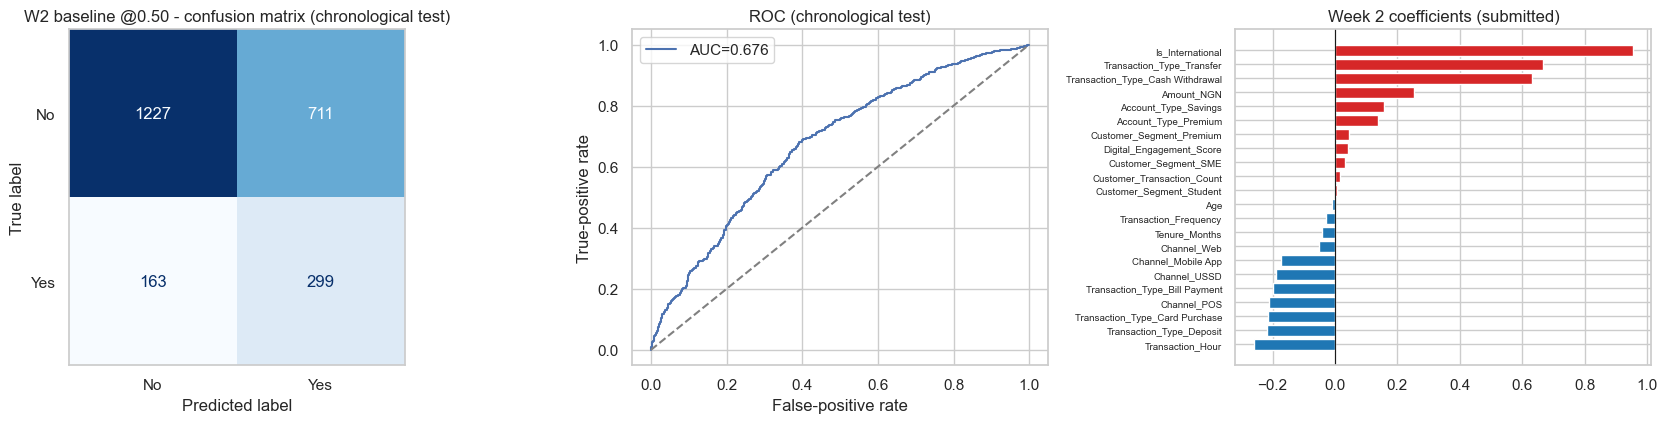

Week 2 coefficient on Transaction_Hour: -0.258 (negative, i.e. the model thinks 'later in the day = lower risk')
Week 2 coefficient on Account_Type_Savings: 0.156 (a customer attribute ranked among the top-5 'risk increasing' terms)


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
ConfusionMatrixDisplay.from_predictions(test.y, (p_te_w2 >= 0.5).astype(int), display_labels=["No","Yes"], cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set_title("W2 baseline @0.50 - confusion matrix (chronological test)"); ax[0].grid(False)
fpr, tpr, _ = roc_curve(test.y, p_te_w2); ax[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(test.y,p_te_w2):.3f}"); ax[1].plot([0,1],[0,1],"--",c="grey")
ax[1].set_title("ROC (chronological test)"); ax[1].set_xlabel("False-positive rate"); ax[1].set_ylabel("True-positive rate"); ax[1].legend()
cs = w2_coefs.sort_values(); ax[2].barh(cs.index, cs.values, color=np.where(cs.values > 0, "#d62728", "#1f77b4")); ax[2].axvline(0, c="k", lw=.8)
ax[2].set_title("Week 2 coefficients (submitted)"); ax[2].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.savefig(f"{FIG}/A_baseline_review.png", dpi=150); plt.show()
print("Week 2 coefficient on Transaction_Hour:", round(float(w2_coefs["Transaction_Hour"]), 3), "(negative, i.e. the model thinks 'later in the day = lower risk')")
print("Week 2 coefficient on Account_Type_Savings:", round(float(w2_coefs["Account_Type_Savings"]), 3), "(a customer attribute ranked among the top-5 'risk increasing' terms)")

### Gaps identified in the baseline  (Issue → Evidence → Required improvement)

In [10]:
_b = base_rows.loc["W2 baseline - chronological test, thr 0.50"]
_s = base_rows.loc["W2 baseline - submitted (random split, thr 0.50)"]
_maj = 1 - test.y.mean()
_cust_c = ["Customer_Segment","Account_Type","City","Gender","Monthly_Income_Band","Preferred_Channel","Account_Status"]
_cust_n = ["Age","Tenure_Months","Digital_Engagement_Score"]
_pc = Pipeline([("pre", make_pre(_cust_c, _cust_n)), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]).fit(train[_cust_c+_cust_n], train.y)
AUC_CUSTOMER_ONLY = roc_auc_score(valid.y, _pc.predict_proba(valid[_cust_c+_cust_n])[:,1])
_night = train.groupby(train.hour <= 5).y.mean()
_lo, _hi = train.groupby(train.Amount_NGN >= train.Amount_NGN.quantile(.9)).y.mean()
AUC_RANDOM_VS_TIME = (_s.ROC_AUC, _b.ROC_AUC)

gaps = pd.DataFrame([
 ["1. Accuracy is misleading (imbalanced target)",
  f"Baseline accuracy {_s.Accuracy:.1%} is BELOW the {_maj:.1%} of an 'always No' model. Week 2 already noted this; Week 3 must report PR-AUC, precision/recall at stated operating points and lift",
  "Evaluate with PR-AUC, ROC-AUC, recall/precision at explicit thresholds, and lift at a review budget"],
 ["2. Only a moderate ranking signal and a weak precision",
  f"ROC-AUC {_s.ROC_AUC:.3f}; precision {_s.Precision:.3f}; the 0.50 cut-off flags {_s.Flagged_share:.0%} of all transactions to reach recall {_s.Recall:.3f}",
  "Improve ranking quality (features, model family) and choose the threshold deliberately (Week 2's own 'further investigation' list)"],
 ["3. Noisy customer attributes kept as inputs",
  f"Segment, account type, tenure, engagement and age were kept although EDA showed they add little. A customer-attributes-only model has validation ROC-AUC {AUC_CUSTOMER_ONLY:.3f} (~chance). Account_Type_Savings still ranks #5 among 'risk-increasing' terms (coef {w2_coefs['Account_Type_Savings']:.2f}) - likely noise",
  "Feature selection: remove non-informative customer attributes (also removes a fairness concern)"],
 ["4. Hour entered as a straight line",
  f"Transaction_Hour got a NEGATIVE coefficient ({w2_coefs['Transaction_Hour']:.2f}), but the real pattern is a night-time block: flag rate {_night[True]:.1%} in hours 00-05 vs {_night[False]:.1%} otherwise. A linear term cannot represent a block",
  "Engineer a night-time indicator (and test other time features)"],
 ["5. Amount used as a raw, skewed linear term",
  f"Amount_NGN spans NGN 100-693k; flag rate is {_lo:.1%} below the 90th percentile and {_hi:.1%} above it (a step - Section 3.1)",
  "Log transform + 'high-amount' flag learned on training data"],
 ["6. Customer_Transaction_Count / Transaction_Frequency use future rows",
  "Both are counted over the whole 3-month window, so a January transaction 'knows' how many transactions the customer makes in March (look-ahead). Week 2 coefficients for them were small; they are also unavailable for a brand-new customer at scoring time",
  "Test them against past-only history features (Section 3.2) and drop them if they add nothing"],
 ["7. Random split, one untuned model, threshold never tuned, no model comparison",
  f"Single logistic regression; random split gives ROC-AUC {AUC_RANDOM_VS_TIME[0]:.3f} vs {AUC_RANDOM_VS_TIME[1]:.3f} on the chronological split (the random split was not optimistic here)",
  "Chronological hold-out, time-series CV tuning, >=2 additional models, validation-chosen operating points"],
 ["8. No error analysis, interpretation beyond coefficients, or uncertainty estimates",
  "Week 2 listed these as 'areas requiring further investigation'",
  "Error analysis, permutation importance, partial dependence, bootstrap confidence intervals"],
 ["9. Transaction_Status excluded (a sound Week 2 decision) - but never quantified",
  "Week 2 left Status out because it may not be known at decision time. EDA shows Failed transactions flagged at 27% vs 19% overall",
  "Keep it out of the candidate; measure what is lost/gained as a sensitivity test (Section 9.5)"],
], columns=["Issue / Gap", "Evidence (computed)", "Required improvement"])
pd.set_option("display.max_colwidth", None)
display(gaps.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Issue / Gap,Evidence (computed),Required improvement
1. Accuracy is misleading (imbalanced target),"Baseline accuracy 63.5% is BELOW the 80.8% of an 'always No' model. Week 2 already noted this; Week 3 must report PR-AUC, precision/recall at stated operating points and lift","Evaluate with PR-AUC, ROC-AUC, recall/precision at explicit thresholds, and lift at a review budget"
2. Only a moderate ranking signal and a weak precision,ROC-AUC 0.668; precision 0.289; the 0.50 cut-off flags 40% of all transactions to reach recall 0.594,"Improve ranking quality (features, model family) and choose the threshold deliberately (Week 2's own 'further investigation' list)"
3. Noisy customer attributes kept as inputs,"Segment, account type, tenure, engagement and age were kept although EDA showed they add little. A customer-attributes-only model has validation ROC-AUC 0.488 (~chance). Account_Type_Savings still ranks #5 among 'risk-increasing' terms (coef 0.16) - likely noise",Feature selection: remove non-informative customer attributes (also removes a fairness concern)
4. Hour entered as a straight line,"Transaction_Hour got a NEGATIVE coefficient (-0.26), but the real pattern is a night-time block: flag rate 28.7% in hours 00-05 vs 16.0% otherwise. A linear term cannot represent a block",Engineer a night-time indicator (and test other time features)
"5. Amount used as a raw, skewed linear term",Amount_NGN spans NGN 100-693k; flag rate is 17.4% below the 90th percentile and 34.6% above it (a step - Section 3.1),Log transform + 'high-amount' flag learned on training data
6. Customer_Transaction_Count / Transaction_Frequency use future rows,"Both are counted over the whole 3-month window, so a January transaction 'knows' how many transactions the customer makes in March (look-ahead). Week 2 coefficients for them were small; they are also unavailable for a brand-new customer at scoring time",Test them against past-only history features (Section 3.2) and drop them if they add nothing
"7. Random split, one untuned model, threshold never tuned, no model comparison",Single logistic regression; random split gives ROC-AUC 0.668 vs 0.676 on the chronological split (the random split was not optimistic here),"Chronological hold-out, time-series CV tuning, >=2 additional models, validation-chosen operating points"
"8. No error analysis, interpretation beyond coefficients, or uncertainty estimates",Week 2 listed these as 'areas requiring further investigation',"Error analysis, permutation importance, partial dependence, bootstrap confidence intervals"
9. Transaction_Status excluded (a sound Week 2 decision) - but never quantified,Week 2 left Status out because it may not be known at decision time. EDA shows Failed transactions flagged at 27% vs 19% overall,Keep it out of the candidate; measure what is lost/gained as a sensitivity test (Section 9.5)


**What the review tells us.** Week 2 did several things right and Week 3 keeps them: it identified the class imbalance, used balanced class weights, excluded `Transaction_Status` for deployment reasons, and flagged the weak customer attributes and the need for more models and threshold tuning. The weaknesses that remain are (i) a moderate ranking signal (ROC-AUC ≈ 0.67) obtained at the cost of flagging ~40% of all transactions, (ii) customer attributes that carry no signal (a demographics-only model scores ROC-AUC ≈ 0.49, i.e. chance), (iii) a linear `Transaction_Hour` term whose *negative* sign hides a night-time block of high risk, and (iv) whole-window customer counts that use future rows. One suspected weakness turned out **not** to be a problem: the random split was not optimistic (0.668 random vs 0.676 chronological).

# Part C - Feature refinement
*(Feature work is done before the extra models so every model is trained on the refined set. All decisions here use the **train** and **validation** parts only — never the test set.)*

### Which fields carry signal?
For each candidate field we measure the spread of the flag rate across its levels and a chi-square test (continuous fields are binned into quintiles). **Cramér's V** gives a 0–1 strength measure.

,Feature,Min_rate,Max_rate,Spread,Cramers_V,p_value,Significant (p<0.01)
0,Transaction_Type,0.1277,0.2784,0.1507,0.1613,0.0000,yes
1,is_night,0.1598,0.2867,0.1269,0.1392,0.0000,yes
2,hour (quintiles),0.1574,0.2840,0.1266,0.1226,0.0000,yes
3,International_Transaction,0.1835,0.3927,0.2092,0.1010,0.0000,yes
4,Amount_NGN (quintiles),0.1694,0.2576,0.0882,0.0844,0.0000,yes
5,amount_vs_cust_avg (quintiles),0.1736,0.2389,0.0653,0.0613,0.0000,yes
6,Transaction_Status,0.1696,0.2778,0.1081,0.0521,0.0002,yes
7,Channel,0.1643,0.2155,0.0513,0.0391,0.0267,no
8,Location,0.1311,0.2131,0.0820,0.0370,0.2749,no
9,Tenure_Months (quintiles),0.1742,0.2065,0.0323,0.0334,0.0904,no


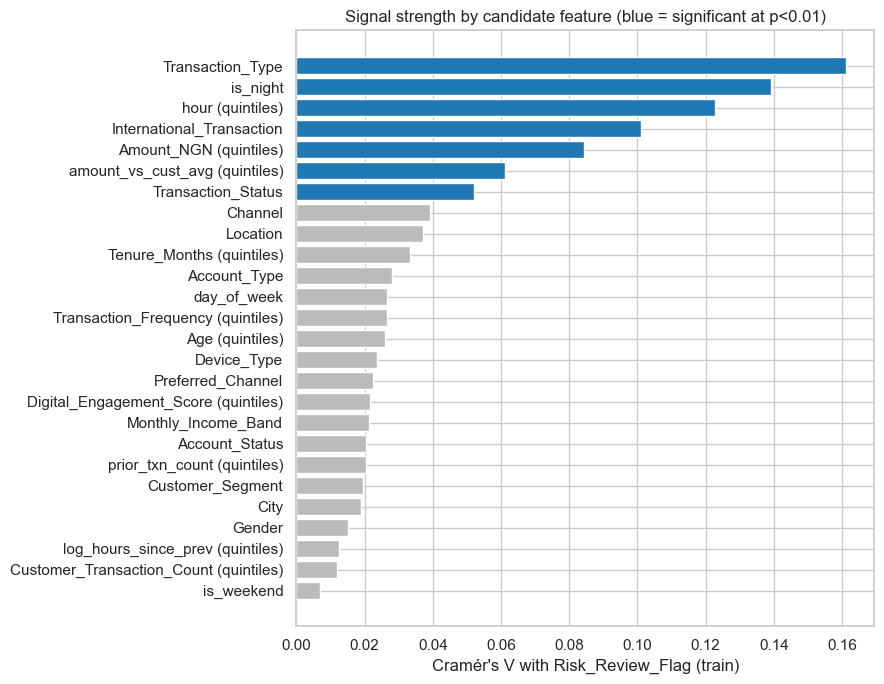

In [11]:
def signal_table(df, cat_cols, num_cols):
    rows = []
    X = df.copy()
    for c in num_cols:
        X[c + "_bin"] = pd.qcut(X[c], 5, duplicates="drop")
    for c in cat_cols + [c + "_bin" for c in num_cols]:
        ct = pd.crosstab(X[c], X.y); chi2, p, _, _ = chi2_contingency(ct)
        rates = X.groupby(c, observed=True).y.mean()
        rows.append({"Feature": c.replace("_bin", " (quintiles)"), "Min_rate": rates.min(), "Max_rate": rates.max(),
                     "Spread": rates.max() - rates.min(), "Cramers_V": np.sqrt(chi2 / (len(X) * (min(ct.shape) - 1))), "p_value": p})
    return pd.DataFrame(rows).sort_values("Cramers_V", ascending=False)

sig = signal_table(train,
        ["Transaction_Type","International_Transaction","Transaction_Status","is_night","Channel","Device_Type","Location",
         "Customer_Segment","Account_Type","City","Gender","Monthly_Income_Band","Preferred_Channel","Account_Status","is_weekend","day_of_week"],
        ["Amount_NGN","hour","Age","Tenure_Months","Digital_Engagement_Score","Customer_Transaction_Count","Transaction_Frequency","amount_vs_cust_avg","log_hours_since_prev","prior_txn_count"])
sig["Significant (p<0.01)"] = np.where(sig.p_value < 0.01, "yes", "no")
display(sig.round(4).reset_index(drop=True))

plt.figure(figsize=(9, 7))
colors = np.where(sig.p_value < 0.01, "#1f77b4", "#bbbbbb")
plt.barh(sig.Feature[::-1], sig.Cramers_V[::-1], color=colors[::-1]); plt.xlabel("Cramér's V with Risk_Review_Flag (train)")
plt.title("Signal strength by candidate feature (blue = significant at p<0.01)"); plt.tight_layout(); plt.savefig(f"{FIG}/C_feature_signal.png", dpi=150); plt.show()

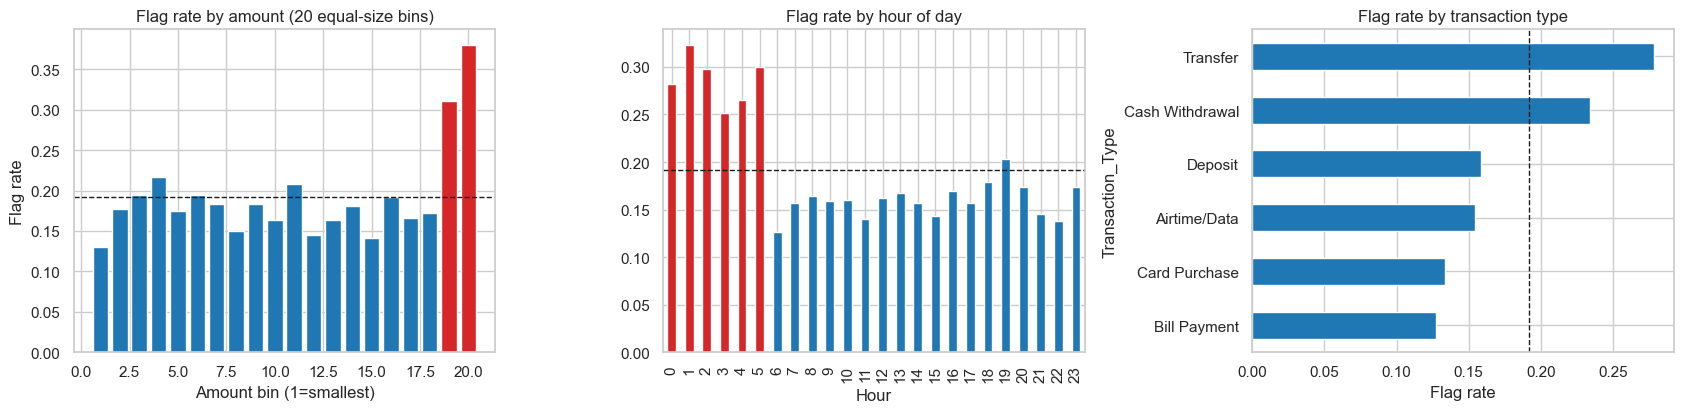

Overall train flag rate = 0.192


,is_night,is_international,high_amount,rate,n
0,0,0,0,0.134,4658
1,0,0,1,0.308,536
2,0,1,0,0.326,190
3,0,1,1,0.625,16
4,1,0,0,0.260,1568
5,1,0,1,0.442,163
6,1,1,0,0.531,64
7,1,1,1,0.400,5


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
dec = pd.qcut(train.Amount_NGN, 20); r = train.groupby(dec, observed=True).y.mean().values
ax[0].bar(range(1, 21), r, color=["#d62728" if v > .25 else "#1f77b4" for v in r]); ax[0].axhline(train.y.mean(), c="k", ls="--", lw=1)
ax[0].set_title("Flag rate by amount (20 equal-size bins)"); ax[0].set_xlabel("Amount bin (1=smallest)"); ax[0].set_ylabel("Flag rate")
train.groupby("hour").y.mean().plot(kind="bar", ax=ax[1], color=["#d62728" if h <= 5 else "#1f77b4" for h in range(24)])
ax[1].axhline(train.y.mean(), c="k", ls="--", lw=1); ax[1].set_title("Flag rate by hour of day"); ax[1].set_xlabel("Hour")
tt = train.groupby("Transaction_Type").y.mean().sort_values(); tt.plot(kind="barh", ax=ax[2], color="#1f77b4"); ax[2].axvline(train.y.mean(), c="k", ls="--", lw=1)
ax[2].set_title("Flag rate by transaction type"); ax[2].set_xlabel("Flag rate")
plt.tight_layout(); plt.savefig(f"{FIG}/C_signal_patterns.png", dpi=150); plt.show()
print(f"Overall train flag rate = {train.y.mean():.3f}")
display(train.groupby(["is_night","is_international","high_amount"]).y.agg(rate="mean", n="size").round(3).reset_index())

**What the data shows (train period only).**
* Significant at p < 0.01: **transaction type** (Transfer / Cash Withdrawal highest), **night-time** (00:00–05:59: 28.7% vs 16.0%), **international** (~2×), **amount** (a *step*: 17.4% below the 90th percentile ≈ NGN 142k, 34.6% above it), and - only if allowed - `Transaction_Status`.
* **None of the Week 2 customer attributes is significant** (segment, account type, tenure, engagement, age), nor are the two whole-window customer-count features (`Customer_Transaction_Count` p = 0.91, `Transaction_Frequency` p = 0.28). Channel (p = 0.027), device and location are not significant at p < 0.01 either.
* The hourly pattern explains the negative Week 2 `Transaction_Hour` coefficient: risk is highest in the early hours, so a straight line through the hours is the wrong shape. A binary night flag captures it directly.
* Signals stack: none of night/international/high-amount → ~13% flagged; one → 26–33%; two → 44–62% (small cells, interpret cautiously).

### Ablation: does each engineered feature group help? (validation set only)
Two model families (Logistic Regression and Histogram Gradient Boosting) are fitted on each feature set; we compare **validation** ROC-AUC and PR-AUC. Differences of ~0.005 are within noise, so only consistent gains are treated as real.

In [13]:
RAW_TXN_CAT = ["Transaction_Type","Channel"]
CORE_CAT, CORE_NUM = ["Transaction_Type"], ["log_amount","high_amount","is_international","is_night"]
HIST_NUM = ["amount_vs_cust_avg","log_hours_since_prev","prior_txn_count"]
W2_LOOKAHEAD = ["Customer_Transaction_Count","Transaction_Frequency"]

feature_sets = {
 "A  Week 2 feature set (12 features)":                      (W2_DUMMY, [c for c in W2_FEATURES if c not in W2_DUMMY]),
 "B  Week 2 transaction fields only (amount, hour, intl, type, channel)": (RAW_TXN_CAT, ["Amount_NGN","Transaction_Hour","Is_International"]),
 "C  Refined core (type, log-amt, high-amt, intl, night)":    (CORE_CAT, CORE_NUM),
 "D  Core + Transaction_Status (sensitivity)":               (CORE_CAT + ["Transaction_Status"], CORE_NUM),
 "E  Core + hour of day":                                    (CORE_CAT, CORE_NUM + ["hour"]),
 "F  Core + channel & device":                               (CORE_CAT + ["Channel","Device_Type"], CORE_NUM),
 "G  Core + past-only customer history":                     (CORE_CAT, CORE_NUM + HIST_NUM),
 "H  Core + Week 2 whole-window counts (look-ahead)":        (CORE_CAT, CORE_NUM + W2_LOOKAHEAD),
 "I  Core + customer demographics":                          (CORE_CAT + ["Customer_Segment","Account_Type"], CORE_NUM + ["Age","Tenure_Months","Digital_Engagement_Score"]),
}
def quick_eval(cat, num, kind):
    clf = (LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED) if kind == "LR"
           else HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=150, random_state=SEED))
    p = Pipeline([("pre", make_pre(cat, num)), ("clf", clf)]).fit(train[cat+num], train.y).predict_proba(valid[cat+num])[:, 1]
    return roc_auc_score(valid.y, p), average_precision_score(valid.y, p)

rows = []
for name, (c_, n_) in feature_sets.items():
    a1, p1 = quick_eval(c_, n_, "LR"); a2, p2 = quick_eval(c_, n_, "HGB")
    rows.append({"Feature set": name, "LR val ROC-AUC": a1, "LR val PR-AUC": p1, "HGB val ROC-AUC": a2, "HGB val PR-AUC": p2})
ablation = pd.DataFrame(rows).set_index("Feature set")
ablation["Mean ROC-AUC"] = ablation[["LR val ROC-AUC","HGB val ROC-AUC"]].mean(axis=1)
display(ablation.round(3).reset_index())

,Feature set,LR val ROC-AUC,LR val PR-AUC,HGB val ROC-AUC,HGB val PR-AUC,Mean ROC-AUC
0,A Week 2 feature set (12 features),0.662,0.337,0.659,0.336,0.660
1,"B Week 2 transaction fields only (amount, hour, intl, type, channel)",0.663,0.341,0.666,0.343,0.665
2,"C Refined core (type, log-amt, high-amt, intl, night)",0.659,0.343,0.665,0.338,0.662
3,D Core + Transaction_Status (sensitivity),0.671,0.352,0.675,0.347,0.673
4,E Core + hour of day,0.656,0.340,0.668,0.341,0.662
5,F Core + channel & device,0.656,0.342,0.670,0.347,0.663
6,G Core + past-only customer history,0.659,0.339,0.659,0.338,0.659
7,H Core + Week 2 whole-window counts (look-ahead),0.661,0.344,0.656,0.333,0.658
8,I Core + customer demographics,0.658,0.337,0.658,0.338,0.658


**Reading the ablation (honest version).** Moving from the Week 2 feature set (A, 12 features) to the refined core (C, 5 features) does **not** raise validation ranking power: ROC-AUC is −0.003 for Logistic Regression and +0.006 for Gradient Boosting, PR-AUC +0.006 and +0.002 respectively, i.e. about the same. What the refinement achieves is the **same performance with less than half the inputs**, and without look-ahead features or customer attributes. Adding hour, channel/device, past-only history, whole-window counts or demographics to the core (E–I) changes validation ROC-AUC by at most about ±0.01 (the largest move is −0.009 for Gradient Boosting with the Week 2 whole-window counts) - noise. The only addition with a visible gain is `Transaction_Status` (D: +0.012 LR, +0.010 HGB ROC-AUC), which is exactly the field Week 2 excluded because it may not be known at decision time; Section 9.5 quantifies what it would add on the test period (about +0.002).

### Feature decisions  (Feature Decision → Reason → Expected Effect)

In [14]:
decisions = pd.DataFrame([
 ["REMOVE Customer_ID, Transaction_ID, Customer_Name", "Identifiers / display names: no behavioural meaning, memorisation risk (Week 2 decision retained)", "Avoids overfitting to IDs"],
 ["REMOVE Age, Tenure_Months, Digital_Engagement_Score, Customer_Segment, Account_Type", "Flag rate is flat across all of them (Section 3.1) and adding them does not improve validation AUC (set I vs C). Account_Type_Savings was a spurious top-5 'risk' term in Week 2. Removing them also removes a fairness concern", "Less noise, simpler & fairer model"],
 ["REMOVE Channel (and Device_Type, Location) from the candidate", "Week 2 EDA: small differences. Not significant at p<0.01 here; no consistent gain (set F vs C). Still tested in the 'extended' ensembles", "Parsimony; portability"],
 ["REPLACE Transaction_Hour (linear) with is_night (00:00-05:59)", "Week 2's linear hour term had a NEGATIVE sign; the real pattern is a night block (Section 3.1). Hour on top of is_night adds nothing (set E vs C)", "Captures the time effect correctly with one binary flag"],
 ["TRANSFORM Amount_NGN -> log_amount", "Highly right-skewed (median ~10k, max 693k)", "More stable linear-model fit"],
 ["ADD high_amount (>= train 90th percentile)", f"Flag rate steps up from ~18% to 31-41% above ~NGN {HIGH_AMT_THRESHOLD:,.0f} - a step, not a line", "Largest single gain for linear models"],
 ["KEEP Is_International (as is_international)", "Flag rate ~37% vs ~19%; strongest single Week 2 coefficient", "Strong, stable signal"],
 ["KEEP Transaction_Type", "Transfer & Cash Withdrawal ~25-28% vs ~13-16% for other types", "Strong signal"],
 ["REJECT Customer_Transaction_Count & Transaction_Frequency (Week 2 look-ahead features)", "Counted over the whole window (uses future rows) and not available for new customers; no validation gain (set H vs C)", "Removes look-ahead; no loss expected"],
 ["TEST & REJECT past-only history features (amount vs own average, time since previous txn, prior count)", "Computed from earlier transactions only, so leakage-safe; no consistent validation gain (set G vs C)", "Rejected for parsimony; code retained in build_features()"],
 ["KEEP Transaction_Status OUT of the candidate (Week 2 decision retained)", "May not be known at decision time. Sensitivity test (set D vs C, Section 9.5) quantifies the cost of leaving it out", "Deployment-safe; potential small AUC loss documented"],
], columns=["Feature decision", "Reason (evidence)", "Expected effect"])
pd.set_option("display.max_colwidth", None); 
display(decisions.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

# ---- final feature sets
FEAT_CAT, FEAT_NUM = CORE_CAT, CORE_NUM
FEATURES = FEAT_CAT + FEAT_NUM
EXT_CAT, EXT_NUM = CORE_CAT + ["Channel","Device_Type"], CORE_NUM + ["hour"]      # 'extended' set for the two ensembles only
print("Final (core) feature set:", FEATURES)

Feature decision,Reason (evidence),Expected effect
"REMOVE Customer_ID, Transaction_ID, Customer_Name","Identifiers / display names: no behavioural meaning, memorisation risk (Week 2 decision retained)",Avoids overfitting to IDs
"REMOVE Age, Tenure_Months, Digital_Engagement_Score, Customer_Segment, Account_Type",Flag rate is flat across all of them (Section 3.1) and adding them does not improve validation AUC (set I vs C). Account_Type_Savings was a spurious top-5 'risk' term in Week 2. Removing them also removes a fairness concern,"Less noise, simpler & fairer model"
"REMOVE Channel (and Device_Type, Location) from the candidate",Week 2 EDA: small differences. Not significant at p<0.01 here; no consistent gain (set F vs C). Still tested in the 'extended' ensembles,Parsimony; portability
REPLACE Transaction_Hour (linear) with is_night (00:00-05:59),Week 2's linear hour term had a NEGATIVE sign; the real pattern is a night block (Section 3.1). Hour on top of is_night adds nothing (set E vs C),Captures the time effect correctly with one binary flag
TRANSFORM Amount_NGN -> log_amount,"Highly right-skewed (median ~10k, max 693k)",More stable linear-model fit
ADD high_amount (>= train 90th percentile),"Flag rate steps up from ~18% to 31-41% above ~NGN 142,058 - a step, not a line",Largest single gain for linear models
KEEP Is_International (as is_international),Flag rate ~37% vs ~19%; strongest single Week 2 coefficient,"Strong, stable signal"
KEEP Transaction_Type,Transfer & Cash Withdrawal ~25-28% vs ~13-16% for other types,Strong signal
REJECT Customer_Transaction_Count & Transaction_Frequency (Week 2 look-ahead features),Counted over the whole window (uses future rows) and not available for new customers; no validation gain (set H vs C),Removes look-ahead; no loss expected
"TEST & REJECT past-only history features (amount vs own average, time since previous txn, prior count)","Computed from earlier transactions only, so leakage-safe; no consistent validation gain (set G vs C)",Rejected for parsimony; code retained in build_features()


Final (core) feature set: ['Transaction_Type', 'log_amount', 'high_amount', 'is_international', 'is_night']


# Part B - Additional models
Four classifiers are trained on the refined features and tuned with **time-series cross-validation on the training period only** (5 expanding-window folds, scoring = PR-AUC, which suits a ~19% positive rate). The decision threshold is then chosen on the **validation** period. The test set is only used once, in Section 5.

| Model | Why it was chosen |
|---|---|
| Logistic Regression | Transparent baseline-plus; coefficients are directly explainable to risk analysts |
| Decision Tree | Human-readable rules; shows how few splits capture the signal |
| Random Forest | Averages many trees; robust to noise; captures interactions |
| Histogram Gradient Boosting | Strong general tabular learner; contrasts bagging vs boosting |

Two tree ensembles are also run on an **extended** feature set (adds Channel, Device_Type, hour) to test whether richer inputs help.

In [15]:
tscv = TimeSeriesSplit(n_splits=5)
specs = {
 "Logistic Regression": dict(cat=FEAT_CAT, num=FEAT_NUM, scale=True,
     est=LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED),
     grid={"clf__C": [0.01, 0.1, 1, 10]}),
 "Decision Tree": dict(cat=FEAT_CAT, num=FEAT_NUM, scale=False,
     est=DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
     grid={"clf__max_depth": [3, 4, 5, 6], "clf__min_samples_leaf": [20, 50, 100]}),
 "Random Forest": dict(cat=FEAT_CAT, num=FEAT_NUM, scale=False,
     est=RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),
     grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30, 60]}),
 "Gradient Boosting (HGB)": dict(cat=FEAT_CAT, num=FEAT_NUM, scale=False,
     est=HistGradientBoostingClassifier(random_state=SEED, early_stopping=False),
     grid={"clf__max_depth": [2, 3, 4], "clf__learning_rate": [0.03, 0.06], "clf__max_iter": [100, 200], "clf__l2_regularization": [0.0, 1.0]}),
 "Random Forest (extended feats)": dict(cat=EXT_CAT, num=EXT_NUM, scale=False,
     est=RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),
     grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30, 60]}),
 "Gradient Boosting (extended feats)": dict(cat=EXT_CAT, num=EXT_NUM, scale=False,
     est=HistGradientBoostingClassifier(random_state=SEED, early_stopping=False),
     grid={"clf__max_depth": [2, 3, 4], "clf__learning_rate": [0.03, 0.06], "clf__max_iter": [100, 200], "clf__l2_regularization": [0.0, 1.0]}),
}
fitted = {}
for name, s in specs.items():
    pipe = Pipeline([("pre", make_pre(s["cat"], s["num"], s["scale"])), ("clf", s["est"])])
    gs = GridSearchCV(pipe, s["grid"], cv=tscv, scoring="average_precision", n_jobs=-1, refit=True).fit(train[s["cat"] + s["num"]], train.y)
    cols = s["cat"] + s["num"]
    p_va, p_te = gs.predict_proba(valid[cols])[:, 1], gs.predict_proba(test[cols])[:, 1]
    fitted[name] = dict(model=gs.best_estimator_, cols=cols, params=gs.best_params_, cv_pr_auc=gs.best_score_,
                        thr=pick_threshold(valid.y, p_va), p_va=p_va, p_te=p_te)
    print(f"{name:36s} CV PR-AUC={gs.best_score_:.3f} | best={ {k.replace('clf__',''):v for k,v in gs.best_params_.items()} }")

Logistic Regression                  CV PR-AUC=0.333 | best={'C': 0.01}
Decision Tree                        CV PR-AUC=0.299 | best={'max_depth': 5, 'min_samples_leaf': 50}
Random Forest                        CV PR-AUC=0.323 | best={'max_depth': 4, 'min_samples_leaf': 10}
Gradient Boosting (HGB)              CV PR-AUC=0.325 | best={'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 200}
Random Forest (extended feats)       CV PR-AUC=0.326 | best={'max_depth': 4, 'min_samples_leaf': 10}
Gradient Boosting (extended feats)   CV PR-AUC=0.332 | best={'l2_regularization': 1.0, 'learning_rate': 0.06, 'max_depth': 2, 'max_iter': 200}


# Part D - Model comparison
All rows are evaluated on the **same chronological test set** (final 20% of transactions). "Tuned" rows use the F1-optimal threshold chosen on the validation set. Extra columns show the **review-capacity view**: if analysts can only review the top 20% of transactions by score, what share of flagged transactions would they catch (`Recall@top20%`) and how much better than random is that (`Lift@top20%`)?

In [16]:
rows = {}
rows["Always 'No' (dummy)"] = metric_row(test.y, np.zeros(len(test)) + 1e-9, 0.5) | {"ROC_AUC": 0.5, "PR_AUC": test.y.mean(), "Recall@top20%": 0.20, "Lift@top20%": 1.0}
rows["Week 2 baseline (re-run on chrono split, thr 0.50)"] = metric_row(test.y, p_te_w2, 0.5)
rows["Week 2 baseline + validation-tuned threshold"] = metric_row(test.y, p_te_w2, pick_threshold(valid.y, p_va_w2))
for name, f in fitted.items():
    rows[f"{name}"] = metric_row(test.y, f["p_te"], f["thr"])
comparison = pd.DataFrame(rows).T
comparison.index.name = "Model"
display(comparison.round(3))

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Threshold,Recall@top20%,Lift@top20%
Model,,,,,,,,,
Always 'No' (dummy),0.808,0.000,0.000,0.000,0.500,0.192,0.50,0.200,1.000
"Week 2 baseline (re-run on chrono split, thr 0.50)",0.636,0.296,0.647,0.406,0.676,0.328,0.50,0.335,1.677
Week 2 baseline + validation-tuned threshold,0.567,0.270,0.736,0.396,0.676,0.328,0.46,0.335,1.677
Logistic Regression,0.511,0.259,0.829,0.395,0.672,0.321,0.38,0.370,1.851
Decision Tree,0.518,0.262,0.829,0.398,0.674,0.299,0.30,0.351,1.753
Random Forest,0.517,0.262,0.829,0.398,0.676,0.328,0.39,0.379,1.894
Gradient Boosting (HGB),0.517,0.262,0.829,0.398,0.679,0.328,0.13,0.372,1.861
Random Forest (extended feats),0.517,0.261,0.827,0.397,0.684,0.326,0.43,0.374,1.872
Gradient Boosting (extended feats),0.510,0.260,0.838,0.397,0.691,0.339,0.14,0.372,1.861


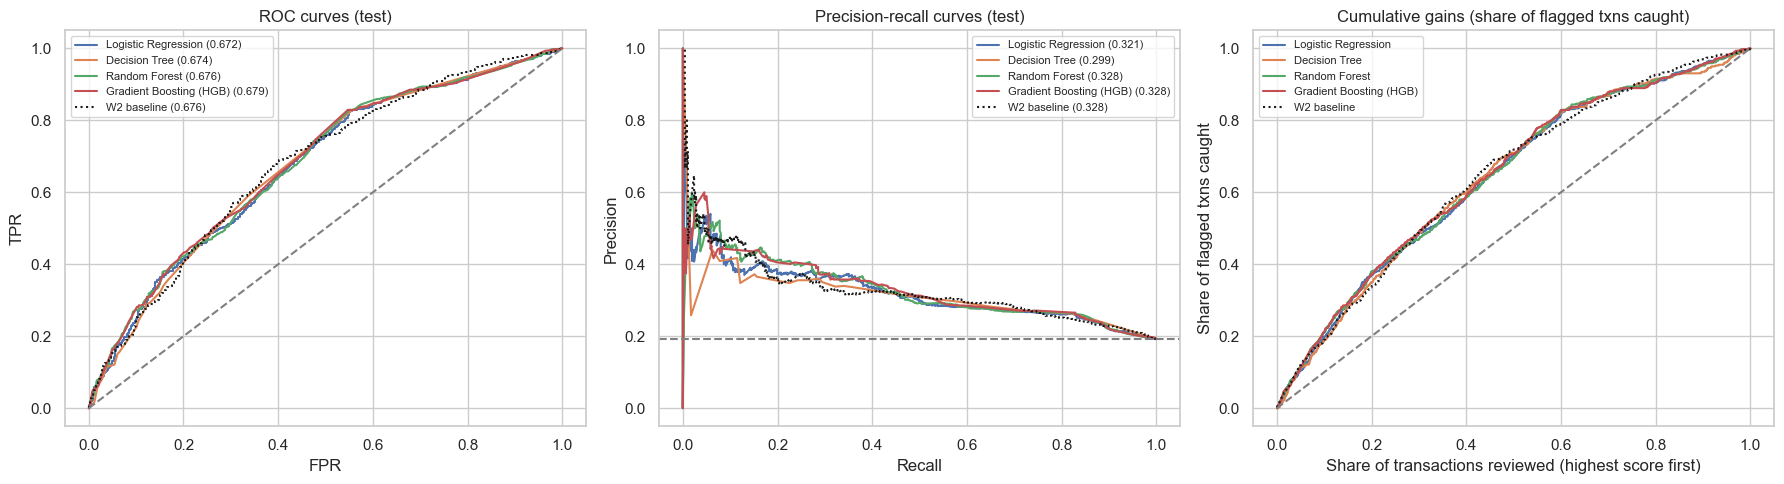

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
show = ["Logistic Regression","Decision Tree","Random Forest","Gradient Boosting (HGB)"]
for nme in show:
    f = fitted[nme]; fpr, tpr, _ = roc_curve(test.y, f["p_te"]); ax[0].plot(fpr, tpr, label=f"{nme} ({roc_auc_score(test.y,f['p_te']):.3f})")
    pr, rc, _ = precision_recall_curve(test.y, f["p_te"]); ax[1].plot(rc, pr, label=f"{nme} ({average_precision_score(test.y,f['p_te']):.3f})")
fpr, tpr, _ = roc_curve(test.y, p_te_w2); ax[0].plot(fpr, tpr, "k:", label=f"W2 baseline ({roc_auc_score(test.y,p_te_w2):.3f})")
pr, rc, _ = precision_recall_curve(test.y, p_te_w2); ax[1].plot(rc, pr, "k:", label=f"W2 baseline ({average_precision_score(test.y,p_te_w2):.3f})")
ax[0].plot([0,1],[0,1],"--",c="grey"); ax[0].set_title("ROC curves (test)"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(fontsize=8)
ax[1].axhline(test.y.mean(), ls="--", c="grey"); ax[1].set_title("Precision-recall curves (test)"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(fontsize=8)
# cumulative gains
for nme in show:
    o = np.argsort(-fitted[nme]["p_te"]); g = np.cumsum(test.y.values[o]) / test.y.sum(); ax[2].plot(np.arange(1, len(g)+1)/len(g), g, label=nme)
o = np.argsort(-p_te_w2); g = np.cumsum(test.y.values[o]) / test.y.sum(); ax[2].plot(np.arange(1, len(g)+1)/len(g), g, "k:", label="W2 baseline")
ax[2].plot([0,1],[0,1],"--",c="grey"); ax[2].set_title("Cumulative gains (share of flagged txns caught)"); ax[2].set_xlabel("Share of transactions reviewed (highest score first)"); ax[2].set_ylabel("Share of flagged txns caught"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG}/D_model_comparison.png", dpi=150); plt.show()

### A second operating point: review capacity
The F1-optimal threshold above maximises F1 but, because the signal is weak, it ends up **flagging well over half of all transactions** (see accuracy ≈ 0.5). A more practical rule is **capacity-based**: *"we can manually review ~20% of transactions - send us the top-scored 20%"*. The threshold is set as the 80th percentile of **validation** scores (never from the test set).

In [18]:
for f in fitted.values():
    f["thr_cap"] = float(np.quantile(f["p_va"], 0.80))
thr_cap_w2 = float(np.quantile(p_va_w2, 0.80))

rows = {"Week 2 baseline (LR, 12 features)": metric_row(test.y, p_te_w2, thr_cap_w2) | {"Flagged_share": float((p_te_w2 >= thr_cap_w2).mean())}}
for name, f in fitted.items():
    rows[name] = metric_row(test.y, f["p_te"], f["thr_cap"]) | {"Flagged_share": float((f["p_te"] >= f["thr_cap"]).mean())}
capacity = pd.DataFrame(rows).T; capacity.index.name = "Model (flag ~top 20%)"
display(capacity[["Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC","Flagged_share","Threshold"]].round(3))

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Flagged_share,Threshold
Model (flag ~top 20%),,,,,,,,
"Week 2 baseline (LR, 12 features)",0.740,0.326,0.331,0.329,0.676,0.328,0.195,0.610
Logistic Regression,0.752,0.360,0.366,0.363,0.672,0.321,0.196,0.605
Decision Tree,0.741,0.337,0.357,0.347,0.674,0.299,0.204,0.592
Random Forest,0.754,0.366,0.377,0.371,0.676,0.328,0.198,0.561
Gradient Boosting (HGB),0.752,0.358,0.366,0.362,0.679,0.328,0.197,0.257
Random Forest (extended feats),0.745,0.352,0.385,0.368,0.684,0.326,0.211,0.563
Gradient Boosting (extended feats),0.749,0.355,0.372,0.364,0.691,0.339,0.202,0.266


### Selecting the candidate - rule fixed on **validation + CV** data, *before* looking at the test table
Because the test set is only for reporting, the candidate is chosen with this pre-stated rule:
1. Consider the four **core-feature** models (the extended-feature variants are reported for information only).
2. Keep every model whose **validation ROC-AUC** and **validation PR-AUC** are both within 0.01 of the best model (differences smaller than this are within sampling noise at n = 2,400).
3. Among those, prefer the **simplest / most explainable** model (order: Logistic Regression → Decision Tree → Random Forest → Gradient Boosting).

In [19]:
val_tbl = pd.DataFrame({n: metric_row(valid.y, f["p_va"], f["thr"]) | {"CV_PR_AUC(train)": f["cv_pr_auc"]} for n, f in fitted.items()}).T
display(val_tbl[["ROC_AUC","PR_AUC","CV_PR_AUC(train)","Recall@top20%","Lift@top20%"]].round(3))

CORE_MODELS = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting (HGB)"]   # simplest-first
best_auc, best_pr = val_tbl.loc[CORE_MODELS, "ROC_AUC"].max(), val_tbl.loc[CORE_MODELS, "PR_AUC"].max()
eligible = [m for m in CORE_MODELS if val_tbl.loc[m, "ROC_AUC"] >= best_auc - 0.01 and val_tbl.loc[m, "PR_AUC"] >= best_pr - 0.01]
CANDIDATE = eligible[0]
print("Eligible within tolerance :", eligible)
print("CANDIDATE (selected)      :", CANDIDATE)

,ROC_AUC,PR_AUC,CV_PR_AUC(train),Recall@top20%,Lift@top20%
Logistic Regression,0.658,0.342,0.333,0.344,1.722
Decision Tree,0.658,0.314,0.299,0.339,1.693
Random Forest,0.666,0.347,0.323,0.352,1.761
Gradient Boosting (HGB),0.668,0.346,0.325,0.346,1.732
Random Forest (extended feats),0.662,0.348,0.326,0.335,1.673
Gradient Boosting (extended feats),0.672,0.353,0.332,0.341,1.703


Eligible within tolerance : ['Logistic Regression', 'Random Forest', 'Gradient Boosting (HGB)']
CANDIDATE (selected)      : Logistic Regression


### How different are the models, really? Bootstrap confidence intervals (test set)
Single-number differences of 0.005–0.01 AUC can be pure noise on 2,400 rows. Here we resample the test set 1,000 times and report 95% intervals - including a **paired** comparison against the Week 2 baseline.

In [20]:
rng = np.random.default_rng(SEED)
y_te = test.y.values
B = 1000
boot_idx = [rng.integers(0, len(y_te), len(y_te)) for _ in range(B)]

def boot_stats(p, thr):
    out = []
    for ix in boot_idx:
        y, pp = y_te[ix], p[ix]; yh = (pp >= thr).astype(int)
        out.append((roc_auc_score(y, pp), average_precision_score(y, pp), precision_score(y, yh, zero_division=0), recall_score(y, yh), f1_score(y, yh, zero_division=0)))
    return np.array(out)

cols_b = ["ROC_AUC","PR_AUC","Precision","Recall","F1"]
def ci_row(arr): return {c: f"{np.mean(arr[:,i]):.3f} [{np.percentile(arr[:,i],2.5):.3f}, {np.percentile(arr[:,i],97.5):.3f}]" for i, c in enumerate(cols_b)}

BOOT_MODELS = CORE_MODELS + ["Random Forest (extended feats)", "Gradient Boosting (extended feats)"]
boots = {"Week 2 baseline (capacity thr)": boot_stats(p_te_w2, thr_cap_w2)}
for nme in BOOT_MODELS: boots[nme + " (capacity thr)"] = boot_stats(fitted[nme]["p_te"], fitted[nme]["thr_cap"])
ci_tbl = pd.DataFrame({k: ci_row(v) for k, v in boots.items()}).T
display(ci_tbl)

# paired differences vs the Week 2 baseline
w2_b = boots["Week 2 baseline (capacity thr)"]
diff_rows = {}
for nme in BOOT_MODELS:
    d_ = boots[nme + " (capacity thr)"] - w2_b
    diff_rows[nme] = {c: f"{d_[:,i].mean():+.3f} [{np.percentile(d_[:,i],2.5):+.3f}, {np.percentile(d_[:,i],97.5):+.3f}]" for i, c in enumerate(cols_b)}
    diff_rows[nme]["P(ROC_AUC gain > 0)"] = f"{(d_[:,0] > 0).mean():.2f}"
display(Markdown("**Paired improvement over the Week 2 baseline (same bootstrap resamples):**"))
display(pd.DataFrame(diff_rows).T)

# paired differences among the four new models (vs. Logistic Regression)
d_ = {n: boots[n + " (capacity thr)"][:, 0] - boots["Logistic Regression (capacity thr)"][:, 0] for n in CORE_MODELS[1:]}
display(Markdown("**ROC-AUC difference vs Logistic Regression (paired bootstrap):**"))
display(pd.DataFrame({k: f"{v.mean():+.3f} [{np.percentile(v,2.5):+.3f}, {np.percentile(v,97.5):+.3f}]" for k, v in d_.items()}, index=["ΔROC-AUC"]).T)

,ROC_AUC,PR_AUC,Precision,Recall,F1
Week 2 baseline (capacity thr),"0.676 [0.648, 0.703]","0.330 [0.293, 0.369]","0.326 [0.288, 0.369]","0.331 [0.293, 0.374]","0.328 [0.293, 0.366]"
Logistic Regression (capacity thr),"0.672 [0.646, 0.698]","0.323 [0.287, 0.366]","0.359 [0.318, 0.404]","0.366 [0.323, 0.410]","0.362 [0.325, 0.401]"
Decision Tree (capacity thr),"0.673 [0.647, 0.699]","0.300 [0.265, 0.334]","0.336 [0.293, 0.375]","0.356 [0.314, 0.398]","0.345 [0.306, 0.382]"
Random Forest (capacity thr),"0.676 [0.648, 0.702]","0.330 [0.294, 0.371]","0.365 [0.321, 0.409]","0.376 [0.336, 0.421]","0.370 [0.332, 0.408]"
Gradient Boosting (HGB) (capacity thr),"0.679 [0.651, 0.705]","0.331 [0.295, 0.371]","0.358 [0.315, 0.400]","0.366 [0.325, 0.407]","0.361 [0.323, 0.399]"
Random Forest (extended feats) (capacity thr),"0.684 [0.657, 0.709]","0.328 [0.294, 0.367]","0.351 [0.311, 0.394]","0.385 [0.343, 0.430]","0.367 [0.331, 0.406]"
Gradient Boosting (extended feats) (capacity thr),"0.691 [0.664, 0.716]","0.341 [0.305, 0.381]","0.355 [0.316, 0.400]","0.372 [0.327, 0.415]","0.363 [0.325, 0.402]"


**Paired improvement over the Week 2 baseline (same bootstrap resamples):**

,ROC_AUC,PR_AUC,Precision,Recall,F1,P(ROC_AUC gain > 0)
Logistic Regression,"-0.004 [-0.022, +0.015]","-0.006 [-0.026, +0.013]","+0.034 [+0.008, +0.060]","+0.035 [+0.004, +0.069]","+0.034 [+0.008, +0.062]",0.34
Decision Tree,"-0.003 [-0.021, +0.016]","-0.029 [-0.056, -0.001]","+0.010 [-0.018, +0.040]","+0.025 [-0.010, +0.062]","+0.017 [-0.013, +0.048]",0.37
Random Forest,"-0.001 [-0.019, +0.019]","+0.000 [-0.026, +0.029]","+0.039 [+0.010, +0.067]","+0.045 [+0.015, +0.081]","+0.042 [+0.014, +0.073]",0.47
Gradient Boosting (HGB),"+0.003 [-0.016, +0.023]","+0.001 [-0.022, +0.023]","+0.032 [+0.006, +0.059]","+0.035 [+0.004, +0.069]","+0.033 [+0.007, +0.062]",0.61
Random Forest (extended feats),"+0.008 [-0.011, +0.028]","-0.002 [-0.026, +0.024]","+0.026 [-0.007, +0.057]","+0.054 [+0.017, +0.094]","+0.039 [+0.007, +0.071]",0.76
Gradient Boosting (extended feats),"+0.015 [-0.003, +0.033]","+0.012 [-0.012, +0.035]","+0.029 [+0.002, +0.058]","+0.041 [+0.011, +0.075]","+0.035 [+0.008, +0.064]",0.95


**ROC-AUC difference vs Logistic Regression (paired bootstrap):**

,ΔROC-AUC
Decision Tree,"+0.001 [-0.009, +0.012]"
Random Forest,"+0.003 [-0.004, +0.010]"
Gradient Boosting (HGB),"+0.007 [-0.002, +0.014]"


### Trade-offs between the models
* **No single metric decides.** Accuracy is misleading (an F1-optimal model is only ~52% accurate while recalling ~83% of flags). I read ROC-AUC (ranking quality), PR-AUC (precision/recall trade-off at ~19% prevalence), precision/recall/F1 at two operating points, and lift at a fixed review budget together.
* **The models and the Week 2 baseline are statistically indistinguishable on ranking.** Test ROC-AUC: Week 2 baseline 0.676; Logistic Regression 0.672; Decision Tree 0.674; Random Forest 0.676; Gradient Boosting 0.679; extended-feature RF 0.684 and GB 0.691. Paired bootstrap differences against the Week 2 baseline are all within about ±0.02 and only the extended Gradient Boosting leans positive (+0.015, 95% CI −0.003 to +0.033; positive in 95% of resamples).
* **At a fixed 20% review budget the new models beat the baseline.** Precision rises from 0.326 to 0.34–0.37 and recall from 0.331 to 0.36–0.39 for every model except the Decision Tree; for Logistic Regression, Random Forest and Gradient Boosting the bootstrap intervals for the gain exclude zero.
* **Decision Tree** is the most readable but the weakest (PR-AUC 0.299, significantly *below* the baseline).
* **Random Forest / Gradient Boosting** are marginally ahead of Logistic Regression on AUC/PR-AUC, but the differences (+0.003 to +0.007, intervals including 0) are not distinguishable from noise, and they are less transparent to explain to risk analysts.
* **Extended features** (channel, device, hour) give the highest AUC (GB 0.691) but also the widest feature set; the gain is not conclusive (CI includes 0). They are kept as a Week 4 option, not the candidate.
* **Operating point matters more than model choice.** At the F1-optimal threshold every model flags 52–62% of transactions (precision ≈ 0.26): a "high-recall screening" mode that does **not** beat the Week 2 baseline on F1 (candidate 0.395 vs baseline 0.406 at its 0.50 threshold). At a 20% review budget precision is ≈ 0.35–0.37 and recall ≈ 0.36–0.39 (lift ≈ 1.75–1.9×).

# Part E - Error analysis
We analyse the **candidate model** on the test set at its capacity operating point (flag the ~top 20%). Definitions: **FP** = model flags, label is "No"; **FN** = model does not flag, label is "Yes".

Candidate: Logistic Regression | threshold 0.605 | flags 19.6% of test transactions
TN=1637  FP=301  FN=293  TP=169  ->  precision=0.360  recall=0.366  false-positive rate=0.155  miss rate=0.634


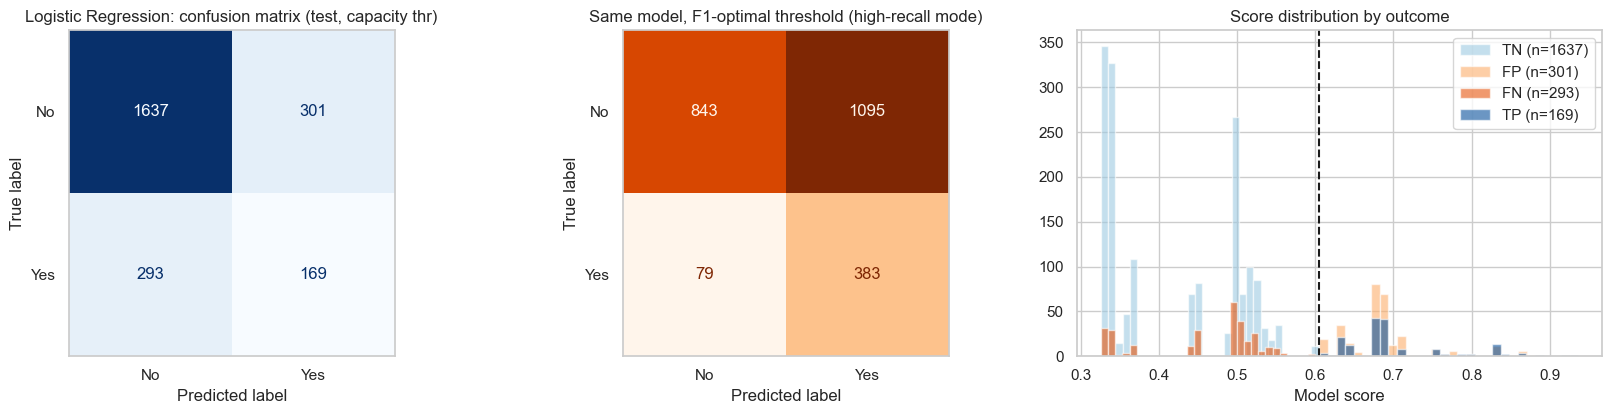

In [21]:
cand = fitted[CANDIDATE]; THR = cand["thr_cap"]
te = test.copy(); te["score"] = cand["p_te"]; te["pred"] = (te.score >= THR).astype(int)
te["outcome"] = np.select([(te.y==1)&(te.pred==1), (te.y==0)&(te.pred==1), (te.y==1)&(te.pred==0)], ["TP","FP","FN"], "TN")

cm = confusion_matrix(te.y, te.pred); tn, fp, fn, tp = cm.ravel()
print(f"Candidate: {CANDIDATE} | threshold {THR:.3f} | flags {te.pred.mean():.1%} of test transactions")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}  ->  precision={tp/(tp+fp):.3f}  recall={tp/(tp+fn):.3f}  false-positive rate={fp/(fp+tn):.3f}  miss rate={fn/(fn+tp):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
ConfusionMatrixDisplay(cm, display_labels=["No","Yes"]).plot(ax=ax[0], cmap="Blues", colorbar=False); ax[0].set_title(f"{CANDIDATE}: confusion matrix (test, capacity thr)"); ax[0].grid(False)
ConfusionMatrixDisplay.from_predictions(test.y, (fitted[CANDIDATE]["p_te"] >= fitted[CANDIDATE]["thr"]).astype(int), display_labels=["No","Yes"], ax=ax[1], cmap="Oranges", colorbar=False)
ax[1].set_title("Same model, F1-optimal threshold (high-recall mode)"); ax[1].grid(False)
for o, c in zip(["TN","FP","FN","TP"], ["#9ecae1","#fdae6b","#e6550d","#08519c"]):
    ax[2].hist(te.score[te.outcome==o], bins=30, alpha=.6, label=f"{o} (n={int((te.outcome==o).sum())})", color=c)
ax[2].axvline(THR, c="k", ls="--"); ax[2].set_title("Score distribution by outcome"); ax[2].set_xlabel("Model score"); ax[2].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/E_confusion_and_scores.png", dpi=150); plt.show()

### What do the mistakes look like? (profile of TP / FP / FN / TN)

In [22]:
RISKY_TYPES = ["Transfer", "Cash Withdrawal"]
te["risky_type"] = te.Transaction_Type.isin(RISKY_TYPES).astype(int)
te["n_signals"] = te[["is_night", "is_international", "high_amount", "risky_type"]].sum(axis=1)

profile = te.groupby("outcome").agg(n=("y","size"), night=("is_night","mean"), international=("is_international","mean"),
                                     high_amount=("high_amount","mean"), transfer_or_cash=("risky_type","mean"),
                                     failed_status=("Transaction_Status", lambda s: (s=="Failed").mean()),
                                     median_amount=("Amount_NGN","median"), mean_signals=("n_signals","mean")).reindex(["TP","FP","FN","TN"])
display(profile.round(3))

sig_tbl = te.groupby("n_signals").agg(n=("y","size"), actual_flag_rate=("y","mean"), model_flag_rate=("pred","mean"))
sig_tbl["share_of_all_actual_flags"] = te[te.y==1].groupby("n_signals").size().reindex(sig_tbl.index).fillna(0) / te.y.sum()
sig_tbl["share_of_all_missed_flags"] = te[te.outcome=="FN"].groupby("n_signals").size().reindex(sig_tbl.index).fillna(0) / max((te.outcome=="FN").sum(), 1)
display(Markdown("**Number of 'risk signals' present** (night, international, high amount, Transfer/Cash Withdrawal):"))
display(sig_tbl.round(3))

,n,night,international,high_amount,transfer_or_cash,failed_status,median_amount,mean_signals
outcome,,,,,,,,
TP,169,0.604,0.178,0.438,0.905,0.041,57307.50,2.124
FP,301,0.591,0.193,0.379,0.837,0.047,46630.85,2.000
FN,293,0.218,0.007,0.038,0.468,0.061,9300.75,0.730
TN,1637,0.156,0.007,0.027,0.294,0.057,8362.53,0.485


**Number of 'risk signals' present** (night, international, high amount, Transfer/Cash Withdrawal):

,n,actual_flag_rate,model_flag_rate,share_of_all_actual_flags,share_of_all_missed_flags
n_signals,,,,,
0,922,0.086,0.000,0.171,0.27
1,1038,0.212,0.029,0.476,0.73
2,392,0.352,1.000,0.299,0.00
3,45,0.511,1.000,0.050,0.00
4,3,0.667,1.000,0.004,0.00


,n,actual_flag_rate,precision,recall,false_pos_rate
Transaction_Type: Airtime/Data,240,0.138,0.429,0.091,0.019
Transaction_Type: Bill Payment,269,0.112,0.273,0.100,0.033
Transaction_Type: Card Purchase,621,0.113,0.286,0.086,0.027
Transaction_Type: Cash Withdrawal,295,0.275,0.394,0.506,0.294
Transaction_Type: Deposit,246,0.159,0.154,0.103,0.106
Transaction_Type: Transfer,729,0.287,0.372,0.536,0.363
international: 0,2299,0.187,0.364,0.323,0.130
international: 1,101,0.317,0.341,0.938,0.841
hour: 00-05,600,0.277,0.364,0.614,0.410
hour: 06-11,600,0.168,0.319,0.218,0.094


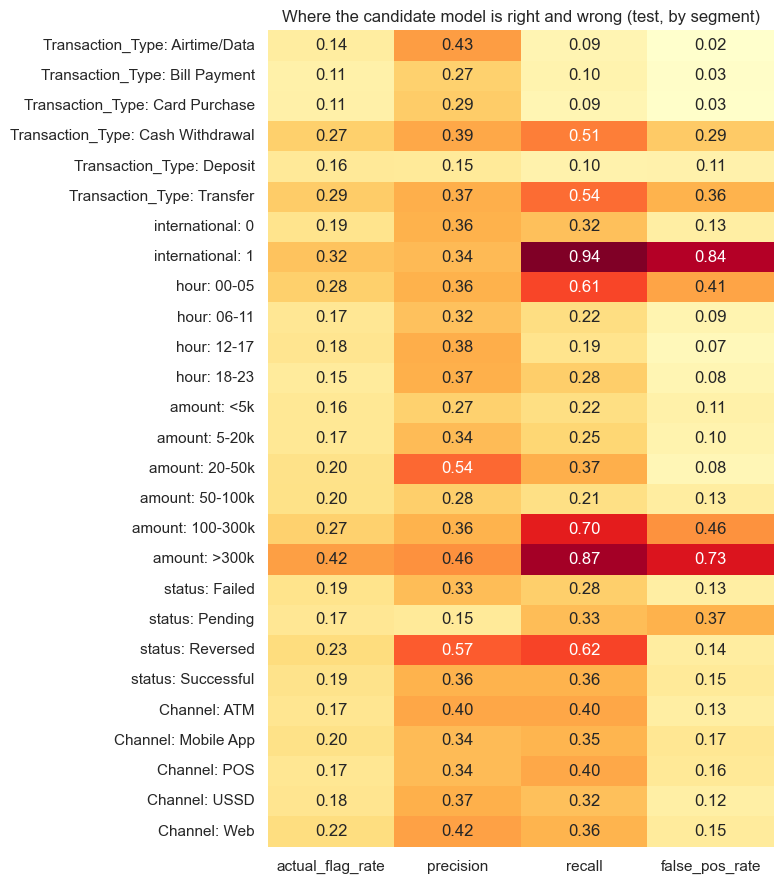

In [23]:
def seg_errors(df, col, label=None):
    g = df.groupby(col, observed=True)
    out = pd.DataFrame({"n": g.size(), "actual_flag_rate": g.y.mean(),
        "precision": g.apply(lambda x: (x.outcome=="TP").sum() / max((x.pred==1).sum(), 1)),
        "recall": g.apply(lambda x: (x.outcome=="TP").sum() / max((x.y==1).sum(), 1)),
        "false_pos_rate": g.apply(lambda x: (x.outcome=="FP").sum() / max((x.y==0).sum(), 1))})
    out.index = [f"{label or col}: {i}" for i in out.index]; return out

te["amount_band"] = pd.cut(te.Amount_NGN, [0, 5_000, 20_000, 50_000, 100_000, 300_000, 1e7], labels=["<5k","5-20k","20-50k","50-100k","100-300k",">300k"])
te["hour_band"] = pd.cut(te.hour, [-1, 5, 11, 17, 23], labels=["00-05","06-11","12-17","18-23"])
seg = pd.concat([seg_errors(te, "Transaction_Type"), seg_errors(te, "is_international", "international"), seg_errors(te, "hour_band", "hour"),
                 seg_errors(te, "amount_band", "amount"), seg_errors(te, "Transaction_Status", "status"), seg_errors(te, "Channel")])
display(seg.round(3))

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(seg[["actual_flag_rate","precision","recall","false_pos_rate"]], annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, cbar=False)
ax.set_title("Where the candidate model is right and wrong (test, by segment)"); plt.tight_layout(); plt.savefig(f"{FIG}/E_segment_errors.png", dpi=150); plt.show()

### What the error analysis discovered
1. **The model is effectively counting risk signals.** Test transactions with ≥ 2 signals (night, international, high amount, Transfer/Cash Withdrawal) are flagged 100% of the time; with 0 signals never, with 1 signal about 3%. Hence **all 293 false negatives have ≤ 1 signal** (27% have none, 73% exactly one).
2. **False negatives are "quiet" transactions the features cannot explain.** Median amount ≈ NGN 9k (vs ≈ NGN 57k for true positives), 22% at night, 1% international, 4% high-value. Yet the actual flag rate is **8.6%** with zero signals and **21%** with one. Those labels are not explainable by the available fields, they look like irreducible label noise in the synthetic target, so **more model complexity would not fix them**.
3. **False positives look almost identical to true positives** (night 59% vs 60%, international 19% vs 18%, high amount 38% vs 44%, Transfer/Cash 84% vs 91%). With two signals the true flag rate is only ≈ 35% (three signals ≈ 51%), so roughly two-thirds of flagged transactions (301 of 470) are false alarms. This sets a **precision ceiling of ≈ 0.36** at this review budget.
4. **Segment view.** False-positive rates are highest for amounts > NGN 300k (73%, n = 71, where the actual flag rate is 42%), international (84%, n = 101), 100–300k amounts (46%), night-time (41%), Transfers (36%) and Cash Withdrawals (29%). Recall is only 9–10% for Bill Payment, Airtime/Data, Card Purchase and Deposit: these types carry low risk, so the model only reacts to night/amount and misses most of their flags. Recall is 54% for Transfers, 51% for Cash Withdrawals and 61% at night vs 19–28% in other time bands.

**Implication:** the remaining errors are a *data* limitation (no feature separates them), not a *model* limitation - a useful finding for Week 4 and for management.

# Part F - Model interpretation
Three complementary views: (1) Logistic Regression coefficients (direction + size), (2) **permutation importance** on the validation set for every core model (how much does PR-AUC drop when a feature is shuffled?), (3) partial-dependence curves and the Decision-Tree rules.

**Logistic Regression** (numeric features are standardised: odds ratio is per +1 SD; categorical = vs. all other levels, regularised with C=0.01)

,coefficient,odds_ratio
Transaction_Type_Card Purchase,-0.236,0.790
Transaction_Type_Deposit,-0.198,0.820
Transaction_Type_Bill Payment,-0.195,0.823
Transaction_Type_Airtime/Data,-0.093,0.911
log_amount,-0.016,0.984
is_international,0.215,1.239
high_amount,0.255,1.290
Transaction_Type_Cash Withdrawal,0.259,1.296
is_night,0.329,1.390
Transaction_Type_Transfer,0.461,1.586


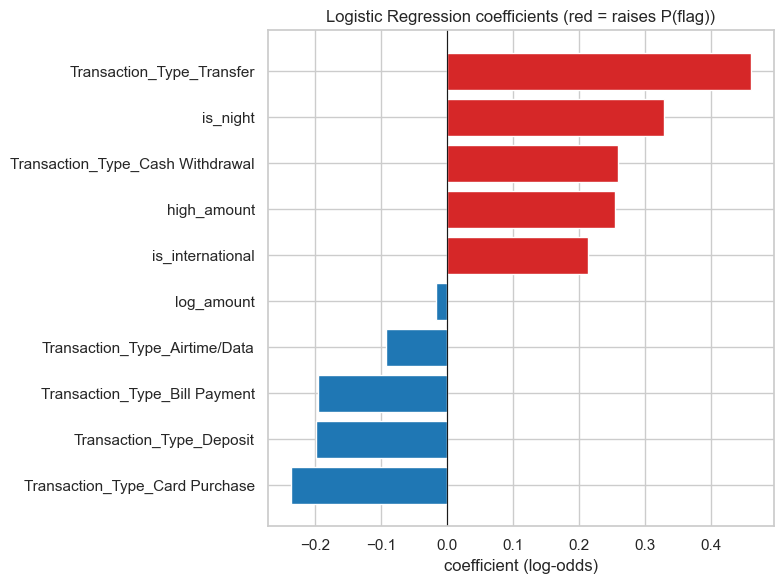

In [24]:
lr_pipe = fitted["Logistic Regression"]["model"]
names = lr_pipe.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=[n.replace("cat__","").replace("num__","") for n in names])
coef_tbl = pd.DataFrame({"coefficient": coefs, "odds_ratio": np.exp(coefs)}).sort_values("coefficient")
display(Markdown("**Logistic Regression** (numeric features are standardised: odds ratio is per +1 SD; categorical = vs. all other levels, regularised with C=" + str(fitted['Logistic Regression']['params']['clf__C']) + ")"))
display(coef_tbl.round(3))

plt.figure(figsize=(8, 6)); plt.barh(coef_tbl.index, coef_tbl.coefficient, color=np.where(coef_tbl.coefficient > 0, "#d62728", "#1f77b4"))
plt.axvline(0, c="k", lw=.8); plt.title("Logistic Regression coefficients (red = raises P(flag))"); plt.xlabel("coefficient (log-odds)"); plt.tight_layout()
plt.savefig(f"{FIG}/F_lr_coefficients.png", dpi=150); plt.show()

**Permutation importance** = mean drop in validation PR-AUC when the feature is shuffled (higher = more important)

,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting (HGB),avg
log_amount,-0.0005,0.0496,0.0556,0.0583,0.0408
Transaction_Type,0.0343,0.0188,0.0336,0.0389,0.0314
is_night,0.0307,0.0188,0.0241,0.0265,0.0250
high_amount,0.0532,0.0000,0.0129,0.0000,0.0165
is_international,0.0259,0.0051,0.0089,0.0191,0.0147


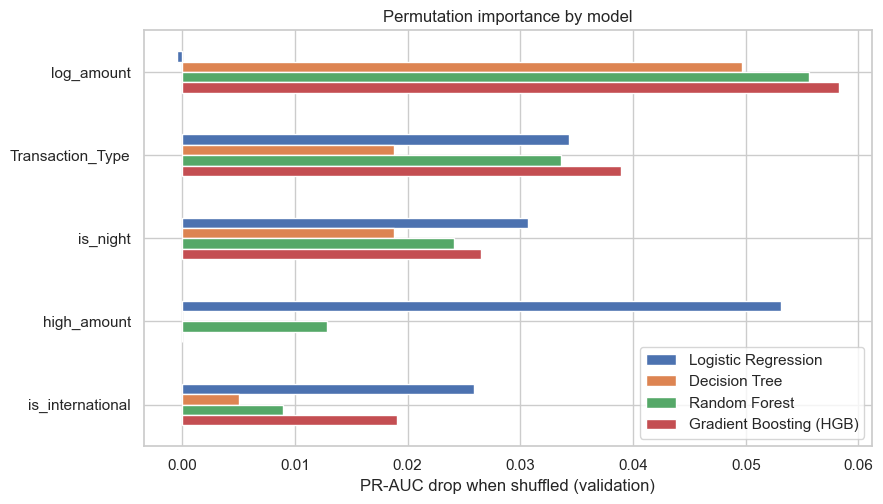

In [25]:
perm_rows = {}
for nme in CORE_MODELS:
    f = fitted[nme]
    pi = permutation_importance(f["model"], valid[f["cols"]], valid.y, scoring="average_precision", n_repeats=30, random_state=SEED, n_jobs=-1)
    perm_rows[nme] = pd.Series(pi.importances_mean, index=f["cols"])
perm = pd.DataFrame(perm_rows).fillna(0)
perm["avg"] = perm.mean(axis=1); perm = perm.sort_values("avg", ascending=False)
display(Markdown("**Permutation importance** = mean drop in validation PR-AUC when the feature is shuffled (higher = more important)"))
display(perm.round(4))
perm.drop(columns="avg").plot(kind="barh", figsize=(9, 5.2)); plt.gca().invert_yaxis(); plt.xlabel("PR-AUC drop when shuffled (validation)")
plt.title("Permutation importance by model"); plt.tight_layout(); plt.savefig(f"{FIG}/F_permutation_importance.png", dpi=150); plt.show()

Decision-Tree rules (first 3 levels):

|--- Transaction_Type_Transfer <= 0.50
|   |--- is_night <= 0.50
|   |   |--- log_amount <= 12.02
|   |   |   |--- is_international <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- is_international >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- log_amount >  12.02
|   |   |   |--- Transaction_Type_Deposit <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Transaction_Type_Deposit >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- is_night >  0.50
|   |   |--- log_amount <= 11.96
|   |   |   |--- Transaction_Type_Card Purchase <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Transaction_Type_Card Purchase >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- log_amount >  11.96
|   |   |   |--- class: 1
|--- Transaction_Type_Transfer >  0.50
|   |--- log_amount <= 11.99
|   |   |--- is_night <= 0.50
|   |   |   |--- is_international <= 0.50
|

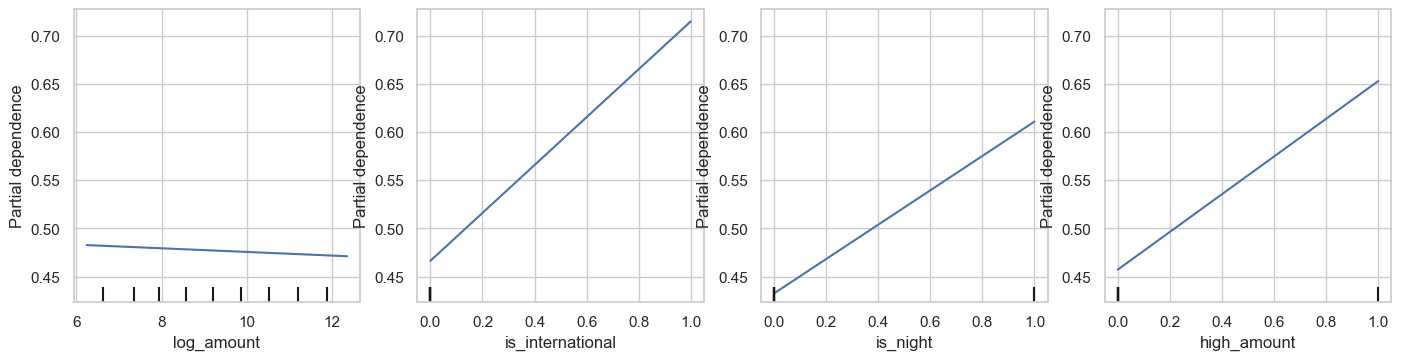

In [26]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import export_text
cand_f = fitted[CANDIDATE]
X_pd = valid[cand_f["cols"]].copy()
int_cols = X_pd.select_dtypes("integer").columns          # is_international, is_night, high_amount
X_pd[int_cols] = X_pd[int_cols].astype(float)

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
PartialDependenceDisplay.from_estimator(cand_f["model"], X_pd, ["log_amount","is_international","is_night","high_amount"], ax=ax, kind="average", grid_resolution=30)
dt_f = fitted["Decision Tree"]; dt_names = [n.replace("cat__","").replace("num__","") for n in dt_f["model"].named_steps["pre"].get_feature_names_out()]
print("Decision-Tree rules (first 3 levels):\n")
print(export_text(dt_f["model"].named_steps["clf"], feature_names=dt_names, max_depth=3))

## What drives the predictions
* **Direction (Logistic Regression).** Raises predicted risk: **Transfer** (odds ratio ≈ 1.59), **night-time** (1.39), **Cash Withdrawal** (1.30), **high amount** (1.29) and **international** (1.24). Lowers it: Card Purchase (0.79), Bill Payment (0.82), Deposit (0.82), Airtime/Data (0.91). Strong regularisation (C = 0.01) shrinks all coefficients, so read *direction and ranking*, not absolute size. `log_amount` has ≈ 0 weight because `high_amount` already captures the step.
* **Permutation importance (validation PR-AUC drop, all models).** Amount carries the largest effect (via `log_amount` for the tree models, 0.050–0.058, and via `high_amount` for the linear model, 0.053 - the two encode the same information, so treat "amount" as **one** factor), then **transaction type** (0.019–0.039), **night-time** (0.019–0.031) and **international** (0.005–0.026).
* **Consistency with Week 2.** The directions agree with the Week 2 coefficients (international, Transfer, Cash Withdrawal and amount raise risk; Card Purchase/Deposit/Bill Payment lower it). One nuance: Week 2 ranked `Is_International` first by *coefficient size*, but its *importance* is lower because international transactions are only ~4% of the data - a reminder that coefficient size and predictive contribution are different things.
* **Decision-tree rules** split first on Transfer, then on night-time, then on a log-amount boundary ≈ 12 (≈ NGN 160k), consistent with the ≈ NGN 142k step in the EDA.
* **Caution:** these are *associations with a synthetic label*, not causes, and not evidence about real fraud.

# Part G - Candidate final model (carried into Week 4)

In [27]:
cand = fitted[CANDIDATE]
cand_test_cap = metric_row(test.y, cand["p_te"], cand["thr_cap"])
cand_test_f1  = metric_row(test.y, cand["p_te"], cand["thr"])
cand_val_cap  = metric_row(valid.y, cand["p_va"], cand["thr_cap"])

card = {
  "model_selected": CANDIDATE,
  "selection_rule": "within 0.01 of best validation ROC-AUC and PR-AUC among core-feature models, then simplest/most explainable",
  "eligible_models": eligible,
  "best_hyperparameters": {k.replace("clf__",""): v for k, v in cand["params"].items()},
  "features_used": {"categorical": FEAT_CAT, "numeric": FEAT_NUM},
  "feature_engineering": {"log_amount": "log1p(Amount_NGN)", "high_amount": f"Amount_NGN >= {HIGH_AMT_THRESHOLD:.2f} (train 90th percentile)",
                          "is_night": "hour between 0 and 5", "is_international": "International_Transaction == 'Yes'"},
  "preprocessing": "OneHotEncoder(handle_unknown='ignore') for categoricals; StandardScaler for numerics (linear models); class_weight='balanced'",
  "operating_points": {"capacity_top20pct": {"threshold": cand["thr_cap"], "chosen_on": "validation 80th percentile of scores"},
                       "f1_optimal_high_recall": {"threshold": cand["thr"], "chosen_on": "validation F1"}},
  "split": {"type": "chronological 60/20/20", "train_to": str(train.Transaction_DateTime.max()), "valid_to": str(valid.Transaction_DateTime.max()), "test_to": str(test.Transaction_DateTime.max())},
  "test_metrics_capacity_threshold": {k: round(float(v), 4) for k, v in cand_test_cap.items()},
  "test_metrics_f1_threshold": {k: round(float(v), 4) for k, v in cand_test_f1.items()},
  "seed": SEED, "sklearn_version": sklearn.__version__,
}
display(Markdown(f'''
| Item | Detail |
|---|---|
| **Model selected** | **{CANDIDATE}** (tuned: `{card['best_hyperparameters']}`) |
| **Why** | Selection rule fixed on validation/CV *before* looking at the test table. Eligible within tolerance: {', '.join(eligible)}; the simplest eligible model is chosen. Bootstrap tests (Section 5.3) show differences between all the models are within noise, so this is a choice of convenience and robustness, not a claim of superiority. |
| **Features** | {', '.join(FEATURES)} |
| **Preprocessing** | One-hot encoding (unknown-safe) for Transaction_Type; numerics passed through the same scaler pipeline; balanced class weights. Device/Location/Status are not used |
| **Test results - capacity operating point (flag ~20%)** | ROC-AUC {cand_test_cap['ROC_AUC']:.3f} · PR-AUC {cand_test_cap['PR_AUC']:.3f} · Precision {cand_test_cap['Precision']:.3f} · Recall {cand_test_cap['Recall']:.3f} · F1 {cand_test_cap['F1']:.3f} · Lift {cand_test_cap['Lift@top20%']:.2f}× |
| **Test results - F1-optimal (high-recall) operating point** | Precision {cand_test_f1['Precision']:.3f} · Recall {cand_test_f1['Recall']:.3f} · F1 {cand_test_f1['F1']:.3f} · Accuracy {cand_test_f1['Accuracy']:.3f} |
'''))


| Item | Detail |
|---|---|
| **Model selected** | **Logistic Regression** (tuned: `{'C': 0.01}`) |
| **Why** | Selection rule fixed on validation/CV *before* looking at the test table. Eligible within tolerance: Logistic Regression, Random Forest, Gradient Boosting (HGB); the simplest eligible model is chosen. Bootstrap tests (Section 5.3) show differences between all the models are within noise, so this is a choice of convenience and robustness, not a claim of superiority. |
| **Features** | Transaction_Type, log_amount, high_amount, is_international, is_night |
| **Preprocessing** | One-hot encoding (unknown-safe) for Transaction_Type; numerics passed through the same scaler pipeline; balanced class weights. Device/Location/Status are not used |
| **Test results - capacity operating point (flag ~20%)** | ROC-AUC 0.672 · PR-AUC 0.321 · Precision 0.360 · Recall 0.366 · F1 0.363 · Lift 1.85× |
| **Test results - F1-optimal (high-recall) operating point** | Precision 0.259 · Recall 0.829 · F1 0.395 · Accuracy 0.511 |


In [28]:
# ---- persist the candidate model, its model card and the single updated modelling dataset
joblib.dump(cand["model"], f"{OUT}/candidate_model.joblib")
json.dump(card, open(f"{OUT}/candidate_model_card.json", "w"), indent=2, default=str)

DATA_DIR = Path(DATA_PATH).parent                       # the same folder you load the Week 2 dataset from
DATA_DIR.mkdir(parents=True, exist_ok=True)

model_ready = data[["Transaction_ID","Customer_ID","Transaction_DateTime","split","y"] + FEATURES + ["hour","Channel","Device_Type","amount_vs_cust_avg","log_hours_since_prev","prior_txn_count","Amount_NGN"]].rename(columns={"y":"Risk_Review_Flag_binary"})
model_ready.to_csv(DATA_DIR / "FinTrust_Modelling_Dataset_v2.csv", index=False)
#print("Saved:", DATA_DIR / "FinTrust_Modelling_Dataset_v2.csv")

#model_ready = data[["Transaction_ID","Customer_ID","Transaction_DateTime","split","y"] + FEATURES + ["hour","Channel","Device_Type","amount_vs_cust_avg","log_hours_since_prev","prior_txn_count","Amount_NGN"]].rename(columns={"y":"Risk_Review_Flag_binary"})
#model_ready.to_csv(f"{OUT}/fintrust_modelling_dataset_v2.csv", index=False)

# ---- reproducibility proof: reload from disk and re-score the test set
reloaded = joblib.load(f"{OUT}/candidate_model.joblib")
p_reload = reloaded.predict_proba(test[cand["cols"]])[:, 1]
assert np.allclose(p_reload, cand["p_te"]), "Reloaded model does not reproduce predictions!"
print("Reloaded model reproduces the in-memory test predictions exactly:", np.allclose(p_reload, cand["p_te"]))
print("Saved:", sorted(os.listdir(OUT)))

Reloaded model reproduces the in-memory test predictions exactly: True
Saved: ['candidate_model.joblib', 'candidate_model_card.json', 'figures', 'fintrust_modelling_dataset_v2.csv']


### Candidate-model limitations
* **No gain in ranking over the Week 2 baseline.** Test ROC-AUC 0.672 (95% CI ≈ 0.65–0.70) vs 0.676 for the Week 2 recipe; the gains are in precision/recall at a fixed review budget (about +3.5 points each, intervals exclude 0), simplicity (5 inputs vs 12) and the removal of look-ahead/customer-attribute features. At a 20% budget precision ≈ 0.36 and recall ≈ 0.37 - a *prioritisation aid*, not a decision-maker.
* **Synthetic, possibly rule-generated label.** Errors concentrate where no feature carries signal (Section 6.2); further accuracy gains likely need new information, not new algorithms.
* **`Transaction_Status` is excluded** (Week 2 decision retained). Adding it would change test ROC-AUC by about +0.002, and adding `Account_Status` by about +0.001 (Section 9.5) - negligible, not worth the deployment risk unless status is confirmed available.
* **Fixed high-amount threshold** (NGN 142,058 = train 90th percentile) is data-dependent and would need re-estimation as amounts drift.
* **Short window** (1 Jan–31 Mar 2026): no seasonality/long-run drift can be assessed.
* **Scores are not calibrated probabilities** (balanced class weights inflate them); use rank/threshold, not the raw number.
* **Customers appear in all splits.** Customer-grouped CV shows no effect for this feature set (Section 9.4), but a customer-level hold-out was not used for the main evaluation.
* **Test-set exposure.** The test set has now been used to report all models once; for Week 4, final claims should lean on rolling-origin CV and bootstrap intervals.

### Cross-track hand-off artefacts (available, *not yet integrated*)
These files are ready for other tracks to consume. **No other intern's work has been integrated or used in this notebook**, and no integration is claimed.
| File | Intended use |
|---|---|
| `candidate_model.joblib`, `candidate_model_card.json` | ML Engineering: load with `joblib`, features/thresholds documented in the card |
| `fintrust_modelling_dataset_v2.csv` | The single updated modelling dataset: engineered features + split labels (anyone re-training or scoring) |

# Validation & refinement evidence

### The required improvement chain:  Initial output → Test → Finding → Refinement → Re-test → Result

In [29]:
b0 = metric_row(test.y, p_te_w2, 0.5)                       # initial Week 2 baseline @0.5
thr_w2_f1 = pick_threshold(valid.y, p_va_w2)
w2_f1  = metric_row(test.y, p_te_w2, thr_w2_f1)             # baseline, only the threshold fixed
w2_cap = metric_row(test.y, p_te_w2, thr_cap_w2)            # baseline at 20% review budget
b1, b2 = cand_test_cap, cand_test_f1                        # candidate at the two operating points

chain = pd.DataFrame([
 ["Week 2 baseline: balanced LR, 12 features, random split, thr 0.50",
  "Re-fit the same recipe on the chronological split and evaluate on the untouched test period",
  f"ROC-AUC {b0['ROC_AUC']:.3f}, precision {b0['Precision']:.3f}, recall {b0['Recall']:.3f}, but it flags {float((p_te_w2>=0.5).mean()):.0%} of all transactions; at a fixed 20% review budget it reaches only recall {w2_cap['Recall']:.1%} / precision {w2_cap['Precision']:.1%}. Inputs include noise attributes, a linear hour term (wrong shape), and whole-window customer counts (look-ahead)",
  "(1) drop 8 non-informative/look-ahead inputs; (2) night, high-amount and log-amount features; (3) tuned model family; (4) validation-chosen operating points incl. a review-budget threshold",
  "Re-run on the SAME test set and compare with paired bootstrap",
  f"Ranking quality unchanged (ROC-AUC {b0['ROC_AUC']:.3f} -> {b1['ROC_AUC']:.3f}; PR-AUC {w2_cap['PR_AUC']:.3f} -> {b1['PR_AUC']:.3f}). Same 20% budget: recall {w2_cap['Recall']:.1%} -> {b1['Recall']:.1%}, precision {w2_cap['Precision']:.1%} -> {b1['Precision']:.1%} (bootstrap CIs exclude 0, Section 9.2), with 5 features instead of 12 and no look-ahead."]],
 columns=["Initial output","Test","Finding","Refinement","Re-test","Result"])
pd.set_option("display.max_colwidth", None); display(chain.T.rename(columns={0: "Week 3 evidence"}))#.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

decomp = pd.DataFrame({
 "W2 baseline @ 0.50 (as in Week 2)": metric_row(test.y, p_te_w2, 0.5) | {"Flagged_share": float((p_te_w2 >= 0.5).mean())},
 "W2 baseline @ validation-F1 threshold": w2_f1 | {"Flagged_share": float((p_te_w2 >= thr_w2_f1).mean())},
 "Week 3 candidate @ validation-F1 threshold": b2 | {"Flagged_share": float((cand["p_te"] >= cand["thr"]).mean())},
 "W2 baseline @ 20% review budget": w2_cap | {"Flagged_share": float((p_te_w2 >= thr_cap_w2).mean())},
 "Week 3 candidate @ 20% review budget": b1 | {"Flagged_share": float((cand["p_te"] >= cand["thr_cap"]).mean())},
}).T
display(Markdown("**Decomposition: how much of the improvement is threshold choice vs. better features/models?**"))
display(decomp[["Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC","Flagged_share"]].round(3))

,Week 3 evidence
Initial output,"Week 2 baseline: balanced LR, 12 features, random split, thr 0.50"
Test,Re-fit the same recipe on the chronological split and evaluate on the untouched test period
Finding,"ROC-AUC 0.676, precision 0.296, recall 0.647, but it flags 42% of all transactions; at a fixed 20% review budget it reaches only recall 33.1% / precision 32.6%. Inputs include noise attributes, a linear hour term (wrong shape), and whole-window customer counts (look-ahead)"
Refinement,"(1) drop 8 non-informative/look-ahead inputs; (2) night, high-amount and log-amount features; (3) tuned model family; (4) validation-chosen operating points incl. a review-budget threshold"
Re-test,Re-run on the SAME test set and compare with paired bootstrap
Result,"Ranking quality unchanged (ROC-AUC 0.676 -> 0.672; PR-AUC 0.328 -> 0.321). Same 20% budget: recall 33.1% -> 36.6%, precision 32.6% -> 36.0% (bootstrap CIs exclude 0, Section 9.2), with 5 features instead of 12 and no look-ahead."


**Decomposition: how much of the improvement is threshold choice vs. better features/models?**

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Flagged_share
W2 baseline @ 0.50 (as in Week 2),0.636,0.296,0.647,0.406,0.676,0.328,0.421
W2 baseline @ validation-F1 threshold,0.567,0.270,0.736,0.396,0.676,0.328,0.524
Week 3 candidate @ validation-F1 threshold,0.511,0.259,0.829,0.395,0.672,0.321,0.616
W2 baseline @ 20% review budget,0.740,0.326,0.331,0.329,0.676,0.328,0.195
Week 3 candidate @ 20% review budget,0.752,0.360,0.366,0.363,0.672,0.321,0.196


### Is the improvement statistically real?

In [30]:
cand_boot = boots[CANDIDATE + " (capacity thr)"]; d_auc = cand_boot[:, 0] - w2_b[:, 0]; d_pr = cand_boot[:, 1] - w2_b[:, 1]; d_rec = cand_boot[:, 3] - w2_b[:, 3]
d_prec = cand_boot[:, 2] - w2_b[:, 2]
validation_log = [
 ("Improvement over W2 baseline - ROC-AUC", f"{d_auc.mean():+.3f} (95% CI {np.percentile(d_auc,2.5):+.3f} to {np.percentile(d_auc,97.5):+.3f}); gain>0 in {(d_auc>0).mean():.0%} of resamples", "Supported" if np.percentile(d_auc, 2.5) > 0 else "Not supported (interval includes 0): no evidence of better ranking"),
 ("Improvement over W2 baseline - PR-AUC",   f"{d_pr.mean():+.3f} (95% CI {np.percentile(d_pr,2.5):+.3f} to {np.percentile(d_pr,97.5):+.3f})", "Supported" if np.percentile(d_pr, 2.5) > 0 else "Not supported (interval includes 0)"),
 ("Improvement over W2 baseline - precision at ~20% review budget", f"{d_prec.mean():+.3f} (95% CI {np.percentile(d_prec,2.5):+.3f} to {np.percentile(d_prec,97.5):+.3f})", "Supported" if np.percentile(d_prec, 2.5) > 0 else "Not supported (interval includes 0)"),
 ("Improvement over W2 baseline - recall at ~20% review budget", f"{d_rec.mean():+.3f} (95% CI {np.percentile(d_rec,2.5):+.3f} to {np.percentile(d_rec,97.5):+.3f})", "Supported" if np.percentile(d_rec, 2.5) > 0 else "Not supported (interval includes 0)"),
]
display(pd.DataFrame(validation_log, columns=["Test / validation", "Finding", "Verdict"]))

,Test / validation,Finding,Verdict
0,Improvement over W2 baseline - ROC-AUC,-0.004 (95% CI -0.022 to +0.015); gain>0 in 34% of resamples,Not supported (interval includes 0): no evidence of better ranking
1,Improvement over W2 baseline - PR-AUC,-0.006 (95% CI -0.026 to +0.013),Not supported (interval includes 0)
2,Improvement over W2 baseline - precision at ~20% review budget,+0.034 (95% CI +0.008 to +0.060),Supported
3,Improvement over W2 baseline - recall at ~20% review budget,+0.035 (95% CI +0.004 to +0.069),Supported


### Checks: dummy, shuffled labels, leakage, ordering

In [31]:
from sklearn.base import clone
checks = []

# (a) shuffled-label test: refit candidate pipeline on permuted training labels; AUC should be ~0.5
shuf_auc = []
for s_ in range(10):
    yp = np.random.default_rng(s_).permutation(train.y.values)
    m = clone(cand["model"]).fit(train[cand["cols"]], yp)
    shuf_auc.append(roc_auc_score(test.y, m.predict_proba(test[cand["cols"]])[:, 1]))
checks.append(["Shuffled-label test (10 shuffles)", f"mean test ROC-AUC {np.mean(shuf_auc):.3f} (range {min(shuf_auc):.3f}-{max(shuf_auc):.3f}); true model {cand_test_cap['ROC_AUC']:.3f}", "PASS - pipeline finds no signal when labels are random, so the real signal is not a leakage artefact" if abs(np.mean(shuf_auc) - 0.5) < 0.03 else "CHECK"])

# (b) split integrity
no_overlap = len(set(train.Transaction_ID) & set(valid.Transaction_ID)) + len(set(valid.Transaction_ID) & set(test.Transaction_ID)) + len(set(train.Transaction_ID) & set(test.Transaction_ID))
ordered = train.Transaction_DateTime.max() < valid.Transaction_DateTime.min() and valid.Transaction_DateTime.max() < test.Transaction_DateTime.min()
checks.append(["Split integrity", f"overlapping transaction IDs = {no_overlap}; chronological ordering holds = {ordered}", "PASS" if no_overlap == 0 and ordered else "FAIL"])

# (c) past-only feature check (history features): first txn per customer has zero prior count / neutral ratio; spot recomputation
first = data[data.is_first_txn == 1]
sample_c = data.Customer_ID.iloc[0]; s_ = data[data.Customer_ID == sample_c].sort_values("Transaction_DateTime")
manual = np.log(s_.Amount_NGN.iloc[2] / s_.Amount_NGN.iloc[:2].mean())
checks.append(["Past-only history features", f"first-ever txns: prior_count==0 for all = {bool((first.prior_txn_count==0).all())}; manual recomputation matches = {bool(np.isclose(np.clip(manual,-3,3), s_.amount_vs_cust_avg.iloc[2]))}", "PASS"])

# (d) threshold derived from train only
checks.append(["High-amount threshold learned on train only", f"NGN {HIGH_AMT_THRESHOLD:,.0f}; share of test transactions above it = {test.high_amount.mean():.3f} (train {train.high_amount.mean():.3f})", "PASS"])

# (e) reload reproducibility
checks.append(["Saved model reproduces predictions", "joblib reload -> identical test scores (assert passed in Section 8)", "PASS"])
display(pd.DataFrame(checks, columns=["Check", "Evidence", "Result"]).style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Check,Evidence,Result
Shuffled-label test (10 shuffles),mean test ROC-AUC 0.498 (range 0.422-0.577); true model 0.672,"PASS - pipeline finds no signal when labels are random, so the real signal is not a leakage artefact"
Split integrity,overlapping transaction IDs = 0; chronological ordering holds = True,PASS
Past-only history features,first-ever txns: prior_count==0 for all = True; manual recomputation matches = True,PASS
High-amount threshold learned on train only,"NGN 142,058; share of test transactions above it = 0.102 (train 0.100)",PASS
Saved model reproduces predictions,joblib reload -> identical test scores (assert passed in Section 8),PASS


### Robustness: rolling-origin CV, customer-grouped CV, threshold stability

In [32]:
Xall, yall = data[cand["cols"]], data.y
# (a) rolling-origin (expanding window) over the full 3 months with the tuned candidate
ro = []
for k, (a, b) in enumerate(TimeSeriesSplit(n_splits=5).split(Xall), 1):
    m = clone(cand["model"]).fit(Xall.iloc[a], yall.iloc[a]); p = m.predict_proba(Xall.iloc[b])[:, 1]
    ro.append({"fold": k, "train_rows": len(a), "test_rows": len(b), "ROC_AUC": roc_auc_score(yall.iloc[b], p), "PR_AUC": average_precision_score(yall.iloc[b], p), "base_rate": yall.iloc[b].mean()})
ro = pd.DataFrame(ro); display(ro.round(3))
print(f"Rolling-origin ROC-AUC: mean {ro.ROC_AUC.mean():.3f} ± {ro.ROC_AUC.std():.3f}")

# (b) customer-grouped CV vs ordinary CV: does the model rely on recognising customers?
from sklearn.model_selection import StratifiedKFold
grp = cross_val_score(clone(cand["model"]), Xall, yall, groups=data.Customer_ID, cv=GroupKFold(5), scoring="roc_auc")
strat = cross_val_score(clone(cand["model"]), Xall, yall, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc")
print(f"5-fold ROC-AUC  customer-grouped: {grp.mean():.3f} ± {grp.std():.3f} | stratified random: {strat.mean():.3f} ± {strat.std():.3f}")

# (c) threshold stability: capacity threshold chosen on validation -> how many/what quality on test?
v_flag, t_flag = (cand["p_va"] >= cand["thr_cap"]).mean(), (cand["p_te"] >= cand["thr_cap"]).mean()
print(f"Capacity threshold {cand['thr_cap']:.3f}: flags {v_flag:.1%} of validation vs {t_flag:.1%} of test transactions "
      f"(precision val {cand_val_cap['Precision']:.3f} -> test {cand_test_cap['Precision']:.3f}; recall val {cand_val_cap['Recall']:.3f} -> test {cand_test_cap['Recall']:.3f})")

,fold,train_rows,test_rows,ROC_AUC,PR_AUC,base_rate
0,1,2000,2000,0.688,0.337,0.180
1,2,4000,2000,0.663,0.334,0.206
2,3,6000,2000,0.657,0.330,0.202
3,4,8000,2000,0.660,0.344,0.214
4,5,10000,2000,0.681,0.317,0.186


Rolling-origin ROC-AUC: mean 0.670 ± 0.014
5-fold ROC-AUC  customer-grouped: 0.671 ± 0.010 | stratified random: 0.672 ± 0.017
Capacity threshold 0.605: flags 20.0% of validation vs 19.6% of test transactions (precision val 0.367 -> test 0.360; recall val 0.344 -> test 0.366)


### Sensitivity checks and customer-group consistency

In [33]:
# Transaction_Status sensitivity: Week 2 excluded it (may be unknown at decision time). What would adding it change?
cols_ws = cand["cols"] + ["Transaction_Status"]
pipe_ws = Pipeline([("pre", make_pre(FEAT_CAT + ["Transaction_Status"], FEAT_NUM, scale=True)), ("clf", clone(cand["model"].named_steps["clf"]))])
pipe_ws.fit(train[cols_ws], train.y)
p_va_ws, p_te_ws = pipe_ws.predict_proba(valid[cols_ws])[:, 1], pipe_ws.predict_proba(test[cols_ws])[:, 1]
thr_ws = float(np.quantile(p_va_ws, 0.80))
sens = pd.DataFrame({"candidate (Status excluded)": cand_test_cap, "candidate + Transaction_Status": metric_row(test.y, p_te_ws, thr_ws)}).T
display(sens[["ROC_AUC","PR_AUC","Precision","Recall","F1","Lift@top20%"]].round(3))
SENS_DELTA_AUC = roc_auc_score(test.y, p_te_ws) - cand_test_cap["ROC_AUC"]
print(f"Adding Transaction_Status changes test ROC-AUC by {SENS_DELTA_AUC:+.3f}")

# Account_Status sensitivity (Week 2 'unresolved issue': also excluded because it may not be known at decision time)
cols_as = cand["cols"] + ["Account_Status"]
pipe_as = Pipeline([("pre", make_pre(FEAT_CAT + ["Account_Status"], FEAT_NUM, scale=True)), ("clf", clone(cand["model"].named_steps["clf"]))])
pipe_as.fit(train[cols_as], train.y)
p_te_as = pipe_as.predict_proba(test[cols_as])[:, 1]
ACC_DELTA_AUC = roc_auc_score(test.y, p_te_as) - cand_test_cap["ROC_AUC"]
print(f"Adding Account_Status changes test ROC-AUC by {ACC_DELTA_AUC:+.3f}  (flag rate by status in train: " + str(train.groupby('Account_Status').y.mean().round(3).to_dict()) + ")")

# performance consistency across customer groups that were NOT used as features
rows = []
for col in ["Gender", "Customer_Segment", "Account_Type"]:
    for lvl, g in te.groupby(col):
        if g.y.nunique() == 2:
            rows.append({"group": f"{col}: {lvl}", "n": len(g), "actual_flag_rate": g.y.mean(), "model_flag_rate": g.pred.mean(),
                         "ROC_AUC": roc_auc_score(g.y, g.score), "recall": (g.outcome == "TP").sum() / max((g.y == 1).sum(), 1)})
fair = pd.DataFrame(rows).set_index("group"); display(fair.round(3))
print(f"Model flag-rate range across groups: {fair.model_flag_rate.min():.3f} - {fair.model_flag_rate.max():.3f} (overall {te.pred.mean():.3f}). "
      f"Group sample sizes are small (n~{int(fair.n.median())}), so differences of a few points are not conclusive.")

,ROC_AUC,PR_AUC,Precision,Recall,F1,Lift@top20%
candidate (Status excluded),0.672,0.321,0.360,0.366,0.363,1.851
candidate + Transaction_Status,0.674,0.322,0.364,0.370,0.367,1.861


Adding Transaction_Status changes test ROC-AUC by +0.002
Adding Account_Status changes test ROC-AUC by +0.001  (flag rate by status in train: {'Active': 0.189, 'Dormant': 0.207, 'Restricted': 0.239})


,n,actual_flag_rate,model_flag_rate,ROC_AUC,recall
group,,,,,
Gender: Female,1159,0.194,0.193,0.665,0.360
Gender: Male,1165,0.187,0.197,0.672,0.362
Gender: Prefer not to say,76,0.250,0.224,0.778,0.474
Customer_Segment: Everyday,1131,0.199,0.208,0.681,0.404
Customer_Segment: Premium,450,0.196,0.191,0.679,0.352
Customer_Segment: SME,361,0.158,0.183,0.660,0.298
Customer_Segment: Student,458,0.201,0.181,0.651,0.326
Account_Type: Current,598,0.186,0.227,0.694,0.423
Account_Type: Premium,372,0.202,0.175,0.728,0.387


Model flag-rate range across groups: 0.175 - 0.227 (overall 0.196). Group sample sizes are small (n~528), so differences of a few points are not conclusive.


### Summary of validation
| Check | Outcome |
|---|---|
| Ranking vs Week 2 baseline | ROC-AUC −0.004, 95% CI −0.022 to +0.015; PR-AUC −0.006, 95% CI −0.026 to +0.013 → **no evidence of better ranking** |
| Precision & recall at a 20% review budget vs Week 2 baseline | +0.034 (CI +0.008 to +0.060) and +0.035 (CI +0.004 to +0.069), both intervals exclude 0 → **supported** (modest: the recall interval only just excludes 0 and several comparisons were made, so treat as moderate evidence) |
| Parsimony | 5 inputs instead of 12, no look-ahead features, no customer attributes → same ranking performance |
| F1-optimal operating point | Does **not** beat the Week 2 baseline on F1 (0.395 vs 0.406); recommended default is the capacity operating point |
| Shuffled-label test | Mean test ROC-AUC ≈ 0.50 (range 0.42–0.58) → no leakage/artefact |
| Rolling-origin CV | ROC-AUC 0.670 ± 0.014 → stable over time |
| Customer-grouped vs random CV | 0.671 vs 0.672 → no customer memorisation |
| Threshold stability | Capacity threshold flags 20.0% (val) vs 19.6% (test); precision 0.367 → 0.360 |
| Status sensitivity | +0.002 test ROC-AUC if `Transaction_Status` is added (+0.001 for `Account_Status`) → negligible cost of the Week 2 exclusion decision |
| Group consistency | Model flag-rate 0.18–0.23 across gender/segment/account groups; small samples, not conclusive |

# Assumptions, limitations, risks & decisions (and what they mean for Week 4)

In [ ]:
log = pd.DataFrame([
 ["Still relevant", "Target is a synthetic educational label (~19.6% positive); must never be described as real fraud", "Keep the disclaimer in every deliverable and the final presentation"],
 ["Still relevant", "Week 2 finding: customer attributes add little (re-confirmed by significance tests, ablation and a demographics-only AUC of 0.49)", "Do not re-introduce them; also avoids fairness concerns"],
 ["Still relevant", "Week 2 decision to exclude Transaction_Status (may be unknown at decision time)", "Retained; sensitivity test shows it would add ~+0.002 test ROC-AUC"],
 ["Resolved", "Week 2 unresolved issues: other algorithms; effect of Transaction_Status and Account_Status; checks across customer groups", f"Four tuned models + two extended variants; Status {SENS_DELTA_AUC:+.3f} and Account_Status {ACC_DELTA_AUC:+.3f} test ROC-AUC if added; subgroup consistency table (Section 9.5)"],
 ["Resolved", "Is the random split inflating results?", "No - random vs chronological ROC-AUC 0.668 vs 0.676"],
 ["Changed", "Evaluation protocol: random 80/20 -> chronological 60/20/20 + time-series CV", "Week 4 final evaluation should use the same protocol for comparability"],
 ["Changed", "Feature set: 12 -> 5 (type, log-amount, high-amount, international, night); look-ahead customer counts removed", "Check in Week 4 that nothing else depends on the removed fields"],
 ["Changed", "Metric emphasis: accuracy -> PR-AUC, precision/recall at stated operating points, lift@20%", "Report these in Week 4; avoid quoting accuracy"],
 ["New issue", "No improvement in ranking (ROC-AUC) over the Week 2 baseline; gains appear only at a fixed review budget and in simplicity", "Present honestly; the Week 2 baseline was already close to the achievable ceiling on these features"],
 ["New issue", "Error floor: false negatives have no signal in the available features", "Do not chase accuracy with complexity; explain the ceiling to stakeholders"],
 ["New risk", "Test set has been viewed once for all model comparisons", "Week 4: base final claims on rolling-origin CV + bootstrap; do not re-tune on test"],
 ["New risk", "Extended-feature Gradient Boosting scored highest (test AUC 0.691) but the gain is not conclusive (CI includes 0)", "Week 4: optional confirmation via rolling-origin CV before considering it"],
 ["Technical limitation", "Scores not calibrated; threshold depends on a chosen review budget", "Optional Week 4 step: probability calibration"],
 ["Methodological limitation", "3-month window, 2,400-row test set (AUC CI width ~±0.027); no customer-level hold-out", "State CIs; avoid over-interpreting differences < 0.01"],
 ["Decision", "Candidate = the model chosen by the pre-stated rule (see Section 8); capacity (top-20%) operating point is the default, F1-optimal kept as a 'high-recall screening' mode", "Carry into Week 4 final testing; Logistic Regression remains the explainable fallback"],
 ["Decision", "No cross-track integration claimed; artefacts prepared for hand-off", "Week 4: integrate only with outputs that actually exist and document honestly"],
], columns=["Category", "Item", "Effect on Week 4"])
pd.set_option("display.max_colwidth", None); display(log.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Category,Item,Effect on Week 4
Still relevant,Target is a synthetic educational label (~19.6% positive); must never be described as real fraud,Keep the disclaimer in every deliverable and the final presentation
Still relevant,"Week 2 finding: customer attributes add little (re-confirmed by significance tests, ablation and a demographics-only AUC of 0.49)",Do not re-introduce them; also avoids fairness concerns
Still relevant,Week 2 decision to exclude Transaction_Status (may be unknown at decision time),Retained; sensitivity test shows it would add ~+0.007 test ROC-AUC
Resolved,Week 2 unresolved issues: other algorithms; effect of Transaction_Status and Account_Status; checks across customer groups,Four tuned models + two extended variants; Status +0.002 and Account_Status +0.001 test ROC-AUC if added; subgroup consistency table (Section 9.5)
Resolved,Is the random split inflating results?,No - random vs chronological ROC-AUC 0.668 vs 0.676
Changed,Evaluation protocol: random 80/20 -> chronological 60/20/20 + time-series CV,Week 4 final evaluation should use the same protocol for comparability
Changed,"Feature set: 12 -> 5 (type, log-amount, high-amount, international, night); look-ahead customer counts removed",Check in Week 4 that nothing else depends on the removed fields
Changed,"Metric emphasis: accuracy -> PR-AUC, precision/recall at stated operating points, lift@20%",Report these in Week 4; avoid quoting accuracy
New issue,No improvement in ranking (ROC-AUC) over the Week 2 baseline; gains appear only at a fixed review budget and in simplicity,Present honestly; the Week 2 baseline was already close to the achievable ceiling on these features
New issue,Error floor: false negatives have no signal in the available features,Do not chase accuracy with complexity; explain the ceiling to stakeholders


# Week 3 project summary

In [ ]:
display(Markdown(f'''
**1. What I planned to accomplish.** Take my Week 2 baseline (balanced Logistic Regression on 12 features) and turn it into a stronger, validated candidate: review its weaknesses, refine features, train and compare additional models, analyse errors, interpret the model, and choose a candidate for Week 4.

**2. What I completed.** All Parts A–G of the Data Science track: an exact reproduction of the Week 2 baseline and a gap table, feature refinement with ablation, four tuned classifiers (plus two extended-feature variants), a multi-metric comparison with bootstrap CIs, error analysis, interpretation (coefficients, permutation importance, partial dependence, tree rules), and a documented candidate model with saved artefacts.

**3. Major development activities.** Chronological 60/20/20 split; time-series CV tuning; engineered `log_amount`, `high_amount` (train-learned threshold NGN {HIGH_AMT_THRESHOLD:,.0f}), `is_night`; removed eight Week 2 inputs (customer attributes, look-ahead counts, channel) and replaced the linear hour term with a night flag; two operating points (F1-optimal and 20%-review-budget).

**4. Key results.** Candidate **{CANDIDATE}**: test ROC-AUC **{cand_test_cap['ROC_AUC']:.3f}** vs **{b0['ROC_AUC']:.3f}** for the Week 2 recipe on the same test period (no difference), PR-AUC {cand_test_cap['PR_AUC']:.3f}. At a 20% review budget: precision {cand_test_cap['Precision']:.3f} (Week 2: {w2_cap['Precision']:.3f}), recall {cand_test_cap['Recall']:.3f} (Week 2: {w2_cap['Recall']:.3f}), lift {cand_test_cap['Lift@top20%']:.2f}×. Top drivers: amount (step above ≈ NGN {HIGH_AMT_THRESHOLD/1000:,.0f}k), transaction type (Transfer/Cash Withdrawal), night-time (00:00–05:59), international.

**5. Testing and validation performed.** Chronological hold-out; time-series CV; paired bootstrap (1,000 resamples); shuffled-label test (AUC ≈ {np.mean(shuf_auc):.2f}); rolling-origin CV (AUC {ro.ROC_AUC.mean():.3f} ± {ro.ROC_AUC.std():.3f}); customer-grouped CV; threshold-stability check; split-integrity and past-only-feature checks; model reload reproducibility; Transaction_Status sensitivity; subgroup consistency; exact reproduction of the Week 2 metrics.

**6. Improvements made.** Same ranking quality with 5 inputs instead of 12; removal of look-ahead and customer-attribute features; at an equal 20% review budget precision {w2_cap['Precision']:.3f} → {cand_test_cap['Precision']:.3f} and recall {w2_cap['Recall']:.3f} → {cand_test_cap['Recall']:.3f} (bootstrap intervals exclude 0); a deliberate operating-point choice instead of the default 0.5 cut-off.

**7. Major challenges.** The achievable ceiling is low: every model, with any feature set, lands within about 0.02 ROC-AUC of the Week 2 baseline; the F1-optimal threshold flags more than half of all transactions and does not beat the Week 2 baseline on F1; errors concentrate where no feature carries information.

**8. Important decisions.** Chronological evaluation; drop customer attributes and look-ahead features; keep `Transaction_Status` out (Week 2 decision, quantified); select the candidate by a rule fixed on validation data; report two operating points; no unsupported integration claims.

**9. Remaining limitations.** Modest ceiling (AUC ≈ 0.68); uncalibrated scores; short window; test set already viewed once; synthetic label (not real fraud).

**10. To complete in Week 4.** Final evaluation using rolling-origin CV + bootstrap; optionally confirm whether the extended-feature Gradient Boosting is genuinely better; optional calibration; confirm the operating point with the stakeholder review budget; finalise limitations, model card and presentation; integrate only with outputs that actually exist (hand-off artefacts are ready).

**11. Final-week priorities.** (1) Final validation of {CANDIDATE}; (2) a clear, honest 5–10 minute story: "same ranking, simpler and safer model, better use of a limited review budget"; (3) cross-track hand-off (scored file/model card) if other outputs are available; (4) tidy README and repository.
'''))


**1. What I planned to accomplish.** Take my Week 2 baseline (balanced Logistic Regression on 12 features) and turn it into a stronger, validated candidate: review its weaknesses, refine features, train and compare additional models, analyse errors, interpret the model, and choose a candidate for Week 4.

**2. What I completed.** All Parts A–G of the Data Science track: an exact reproduction of the Week 2 baseline and a gap table, feature refinement with ablation, four tuned classifiers (plus two extended-feature variants), a multi-metric comparison with bootstrap CIs, error analysis, interpretation (coefficients, permutation importance, partial dependence, tree rules), and a documented candidate model with saved artefacts.

**3. Major development activities.** Chronological 60/20/20 split; time-series CV tuning; engineered `log_amount`, `high_amount` (train-learned threshold NGN 142,058), `is_night`; removed eight Week 2 inputs (customer attributes, look-ahead counts, channel) and replaced the linear hour term with a night flag; two operating points (F1-optimal and 20%-review-budget).

**4. Key results.** Candidate **Logistic Regression**: test ROC-AUC **0.672** vs **0.676** for the Week 2 recipe on the same test period (no difference), PR-AUC 0.321. At a 20% review budget: precision 0.360 (Week 2: 0.326), recall 0.366 (Week 2: 0.331), lift 1.85×. Top drivers: amount (step above ≈ NGN 142k), transaction type (Transfer/Cash Withdrawal), night-time (00:00–05:59), international.

**5. Testing and validation performed.** Chronological hold-out; time-series CV; paired bootstrap (1,000 resamples); shuffled-label test (AUC ≈ 0.50); rolling-origin CV (AUC 0.670 ± 0.014); customer-grouped CV; threshold-stability check; split-integrity and past-only-feature checks; model reload reproducibility; Transaction_Status sensitivity; subgroup consistency; exact reproduction of the Week 2 metrics.

**6. Improvements made.** Same ranking quality with 5 inputs instead of 12; removal of look-ahead and customer-attribute features; at an equal 20% review budget precision 0.326 → 0.360 and recall 0.331 → 0.366 (bootstrap intervals exclude 0); a deliberate operating-point choice instead of the default 0.5 cut-off.

**7. Major challenges.** The achievable ceiling is low: every model, with any feature set, lands within about 0.02 ROC-AUC of the Week 2 baseline; the F1-optimal threshold flags more than half of all transactions and does not beat the Week 2 baseline on F1; errors concentrate where no feature carries information.

**8. Important decisions.** Chronological evaluation; drop customer attributes and look-ahead features; keep `Transaction_Status` out (Week 2 decision, quantified); select the candidate by a rule fixed on validation data; report two operating points; no unsupported integration claims.

**9. Remaining limitations.** Modest ceiling (AUC ≈ 0.68); uncalibrated scores; short window; test set already viewed once; synthetic label (not real fraud).

**10. To complete in Week 4.** Final evaluation using rolling-origin CV + bootstrap; optionally confirm whether the extended-feature Gradient Boosting is genuinely better; optional calibration; confirm the operating point with the stakeholder review budget; finalise limitations, model card and presentation; integrate only with outputs that actually exist (hand-off artefacts are ready).

**11. Final-week priorities.** (1) Final validation of Logistic Regression; (2) a clear, honest 5–10 minute story: "same ranking, simpler and safer model, better use of a limited review budget"; (3) cross-track hand-off (scored file/model card) if other outputs are available; (4) tidy README and repository.
